In [389]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import PercentFormatter

## UCAS Graduate Outcomes — EDA

In [390]:
ucas_clean_df = pd.read_csv('/Users/anatoly/Desktop/Imperial - Data Analytics/Capstone Project/HE Capstone - Final Data Sources/full_ucas_clean.csv')
hesa_clean_df = pd.read_csv('/Users/anatoly/Desktop/Imperial - Data Analytics/Capstone Project/HE Capstone - Final Data Sources/hesa_subject_clean.csv')

In [391]:
ucas_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4808 entries, 0 to 4807
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      4808 non-null   int64 
 1   Subject group HECoS CAH1  4808 non-null   object
 2   Subject group HECoS CAH3  4808 non-null   object
 3   POLAR4 Quintile           4808 non-null   object
 4   Main scheme applicant     4808 non-null   object
 5   Main scheme application   4808 non-null   object
 6   Accepted applicants       4808 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 263.1+ KB


In [392]:
hesa_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1304 entries, 0 to 1303
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   time_period                  1304 non-null   int64 
 1   academic_year                1304 non-null   object
 2   YAG                          1304 non-null   object
 3   qualification_level          1304 non-null   object
 4   sex                          1304 non-null   object
 5   CAH3_code                    1304 non-null   object
 6   CAH3_subject                 1304 non-null   object
 7   grads                        1304 non-null   int64 
 8   grads_uk                     1304 non-null   int64 
 9   unmatched_percent            1304 non-null   object
 10  overseas_percent             1304 non-null   object
 11  matched                      1304 non-null   object
 12  activity_not_captured        1304 non-null   object
 13  no_sust_dest                 1304

In [393]:
ucas_clean_df['Year'].value_counts()

Year
2021    805
2019    804
2020    803
2022    800
2024    800
2023    796
Name: count, dtype: int64

In [394]:
ucas_clean_df['POLAR4 Quintile'].value_counts()

# This data already reveals a slight structural inequality

POLAR4 Quintile
Quintile 5    973
Quintile 4    967
Quintile 3    966
Quintile 2    960
Quintile 1    942
Name: count, dtype: int64

In [395]:
ucas_clean_df['Subject group HECoS CAH3'].value_counts()


Subject group HECoS CAH3
(CAH25-01-03) design studies                       30
(CAH01-01-04) dentistry                            30
(CAH03-01-05) plant sciences                       30
(CAH03-01-06) zoology                              30
(CAH13-01-01) architecture                         30
                                                   ..
(CAH02-04-03) community nursing                    21
(CAH02-02-02) toxicology                           21
(CAH10-01-10) others in engineering                15
(CAH10-03-01) minerals technology                   6
(CAH17-01-09) others in business and management     2
Name: count, Length: 164, dtype: int64

In [396]:
ucas_clean_df['Subject group HECoS CAH1'].value_counts()


Subject group HECoS CAH1
(CAH02) subjects allied to medicine                        672
(CAH19) language and area studies                          556
(CAH10) engineering and technology                         464
(CAH15) social sciences                                    330
(CAH03) biological and sport sciences                      328
(CAH25) design, and creative and performing arts           270
(CAH17) business and management                            242
(CAH06) agriculture, food and related studies              240
(CAH11) computing                                          240
(CAH20) historical, philosophical and religious studies    210
(CAH07) physical sciences                                  209
(CAH24) media, journalism and communications               150
(CAH04) psychology                                         150
(CAH26) geography, earth and environmental studies         150
(CAH01) medicine and dentistry                             120
(CAH13) architecture, building

In [397]:
biv_ucas = ucas_clean_df.groupby(['Subject group HECoS CAH1', 'POLAR4 Quintile'])['Accepted applicants'].sum()


In [398]:
print(biv_ucas.head(10))

Subject group HECoS CAH1             POLAR4 Quintile
(CAH01) medicine and dentistry       Quintile 1          5950
                                     Quintile 2          8605
                                     Quintile 3         11140
                                     Quintile 4         14830
                                     Quintile 5         27985
(CAH02) subjects allied to medicine  Quintile 1         68955
                                     Quintile 2         77010
                                     Quintile 3         83955
                                     Quintile 4         87420
                                     Quintile 5         83590
Name: Accepted applicants, dtype: int64


<b>Summary of the Notes Above</b><br>
This is an interesting observation.

For medicine and densitry, pupils in quintile 5 are over 4 times more likely to be admitted onto one of these programmes (223k vs. 47k). 

For subjects allied to medicine, the different is less start but still exists (668k vs. 551k). 

In [399]:
print(biv_ucas.head())

Subject group HECoS CAH1        POLAR4 Quintile
(CAH01) medicine and dentistry  Quintile 1          5950
                                Quintile 2          8605
                                Quintile 3         11140
                                Quintile 4         14830
                                Quintile 5         27985
Name: Accepted applicants, dtype: int64


In [400]:
# This code converts the headers above into regular columns, rows and labels
biv_ucas = biv_ucas.reset_index()
print(biv_ucas.head())

         Subject group HECoS CAH1 POLAR4 Quintile  Accepted applicants
0  (CAH01) medicine and dentistry      Quintile 1                 5950
1  (CAH01) medicine and dentistry      Quintile 2                 8605
2  (CAH01) medicine and dentistry      Quintile 3                11140
3  (CAH01) medicine and dentistry      Quintile 4                14830
4  (CAH01) medicine and dentistry      Quintile 5                27985


<Axes: title={'center': 'Accepted Pupils by CAH1 Subject Area by POLAR4 Quintile'}, xlabel='Accepted applicants', ylabel='Subject group HECoS CAH1'>

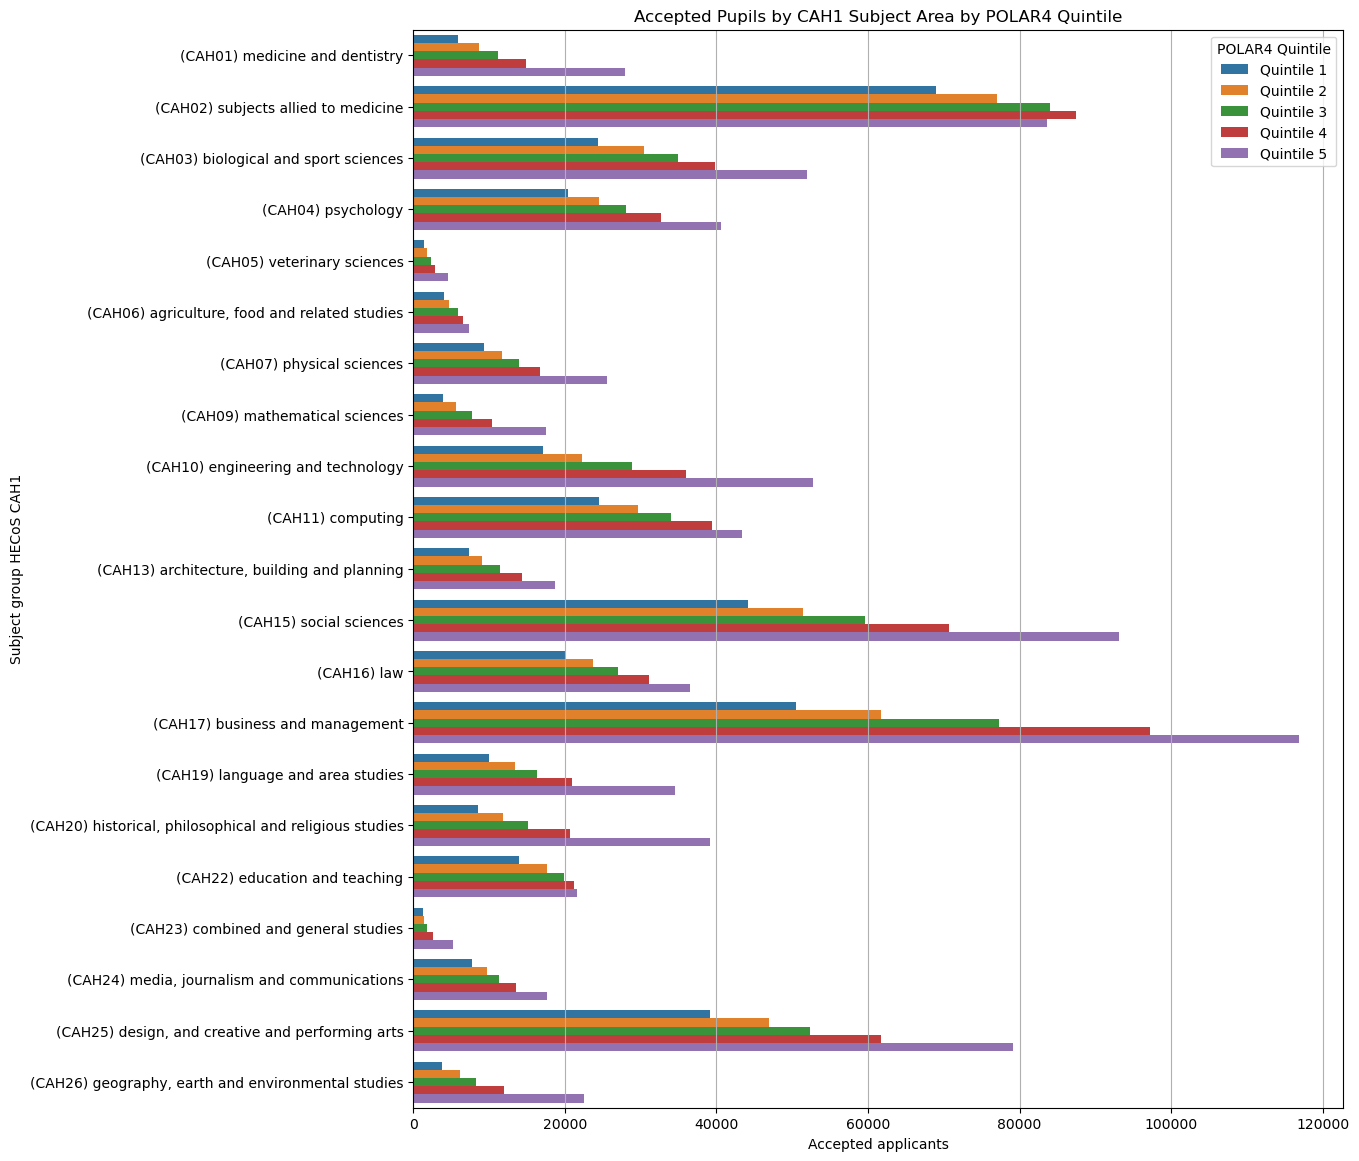

In [401]:
plt.figure(figsize= (12, 14))
plt.grid()
plt.title ('Accepted Pupils by CAH1 Subject Area by POLAR4 Quintile')
sns.barplot(data = biv_ucas,
           x = 'Accepted applicants',
            y = 'Subject group HECoS CAH1',
            hue = 'POLAR4 Quintile',
           )


<b><u>Graph Explanation</b></u><br>
The above graph visualises the number of accepted applicants organised by CAH1 subject area and by POLAR4 quintiles. 

There are a number of key observations we can extract from this data, including:
1. 


In [402]:
ucas_clean_df['Accepted applicants'].sum()

np.int64(2899340)

In [403]:
ucas_clean_df['Accepted applicants'].sum()

np.int64(2899340)

In [404]:
ucas_clean_df.groupby('Subject group HECoS CAH3')['Accepted applicants'].sum().sort_values(ascending=False).head(10)

Subject group HECoS CAH3
(CAH16-01-01) law                                       138380
(CAH04-01-01) psychology (non-specific)                 123680
(CAH17-01-02) business studies                          100980
(CAH02-04-02) adult nursing                              97825
(CAH03-02-01) sport and exercise sciences                97225
(CAH25-01-03) design studies                             95895
(CAH15-01-02) sociology                                  92410
(CAH11-01-01) computer science                           89800
(CAH17-01-01) business and management (non-specific)     86135
(CAH15-02-01) economics                                  62985
Name: Accepted applicants, dtype: int64

In [405]:
ucas_clean_df[ucas_clean_df['Subject group HECoS CAH3'] == '(CAH16-01-01) law']['Accepted applicants'].sum()

np.int64(138380)

In [406]:
ucas_clean_df[ucas_clean_df['Subject group HECoS CAH3'] == '(CAH16-01-01) law'].shape

(30, 7)

In [407]:
ucas_clean_df[ucas_clean_df['Subject group HECoS CAH3'] == '(CAH16-01-01) law']['Year'].value_counts()

Year
2019    5
2020    5
2021    5
2022    5
2023    5
2024    5
Name: count, dtype: int64

In [408]:
biv_ucas_accept_rate = ucas_clean_df.groupby(['Subject group HECoS CAH1'])['Accepted applicants'].sum()

In [409]:
biv_ucas_accept_rate.head()

Subject group HECoS CAH1
(CAH01) medicine and dentistry            68510
(CAH02) subjects allied to medicine      400930
(CAH03) biological and sport sciences    181505
(CAH04) psychology                       146260
(CAH05) veterinary sciences               12885
Name: Accepted applicants, dtype: int64

In [410]:
print(biv_ucas.head())

         Subject group HECoS CAH1 POLAR4 Quintile  Accepted applicants
0  (CAH01) medicine and dentistry      Quintile 1                 5950
1  (CAH01) medicine and dentistry      Quintile 2                 8605
2  (CAH01) medicine and dentistry      Quintile 3                11140
3  (CAH01) medicine and dentistry      Quintile 4                14830
4  (CAH01) medicine and dentistry      Quintile 5                27985


In [496]:
biv_ucas['Acceptance share'] = biv_ucas['Accepted applicants'] / biv_ucas['Subject group HECoS CAH1'].map(biv_ucas_accept_rate)

In [497]:
biv_ucas.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Accepted applicants,Acceptance share
0,(CAH01) medicine and dentistry,Quintile 1,5950,0.086849
1,(CAH01) medicine and dentistry,Quintile 2,8605,0.125602
2,(CAH01) medicine and dentistry,Quintile 3,11140,0.162604
3,(CAH01) medicine and dentistry,Quintile 4,14830,0.216465
4,(CAH01) medicine and dentistry,Quintile 5,27985,0.408481


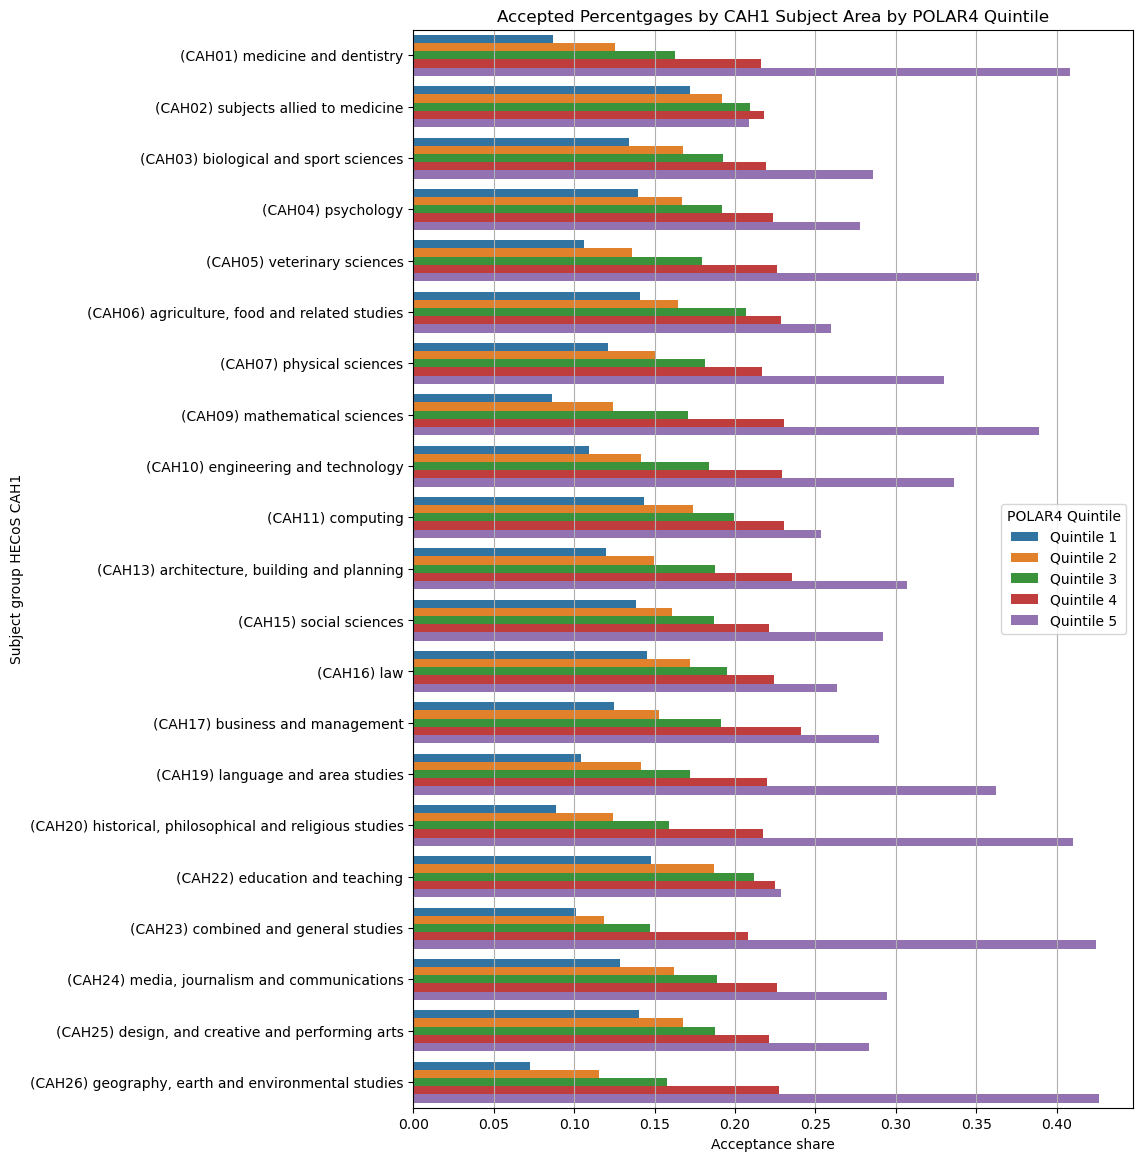

In [498]:
plt.figure(figsize= (12, 14))
plt.grid()
plt.title ('Accepted Percentgages by CAH1 Subject Area by POLAR4 Quintile')
sns.barplot(data = biv_ucas,
           x = 'Acceptance share',
            y = 'Subject group HECoS CAH1',
            hue = 'POLAR4 Quintile',
           )
plt.subplots_adjust(left=0.3)
plt.savefig('Accepted Percentage Split.jpeg')


<b><u>Graph Explanation</b></u><br>
The above graph visualises the percentage split of accepted applicants organised by CAH1 subject area and by POLAR4 quintiles.

Important to note that for subjects allied to medicine, the percentage splits are more even across the board. Interestingly, quintile 4 is actually higher than quintile 5 in this subject area.

### Add Information on this image <!--  -->

In [500]:
pivot_table = pd.pivot_table(biv_ucas, 
                   index = 'Subject group HECoS CAH1', 
                   columns = 'POLAR4 Quintile',
                  values = 'Acceptance share',
                            ).sort_values(by = 'Quintile 1')
pivot_table.index = pivot_table.index.str.split(')').str[1].str.strip()

In [501]:
print(pivot_table.head())

POLAR4 Quintile                                  Quintile 1  Quintile 2  \
Subject group HECoS CAH1                                                  
geography, earth and environmental studies         0.072789    0.115629   
mathematical sciences                              0.086310    0.123918   
medicine and dentistry                             0.086849    0.125602   
historical, philosophical and religious studies    0.088963    0.124318   
combined and general studies                       0.100962    0.118590   

POLAR4 Quintile                                  Quintile 3  Quintile 4  \
Subject group HECoS CAH1                                                  
geography, earth and environmental studies         0.157710    0.227561   
mathematical sciences                              0.170623    0.230197   
medicine and dentistry                             0.162604    0.216465   
historical, philosophical and religious studies    0.159043    0.217373   
combined and general stu

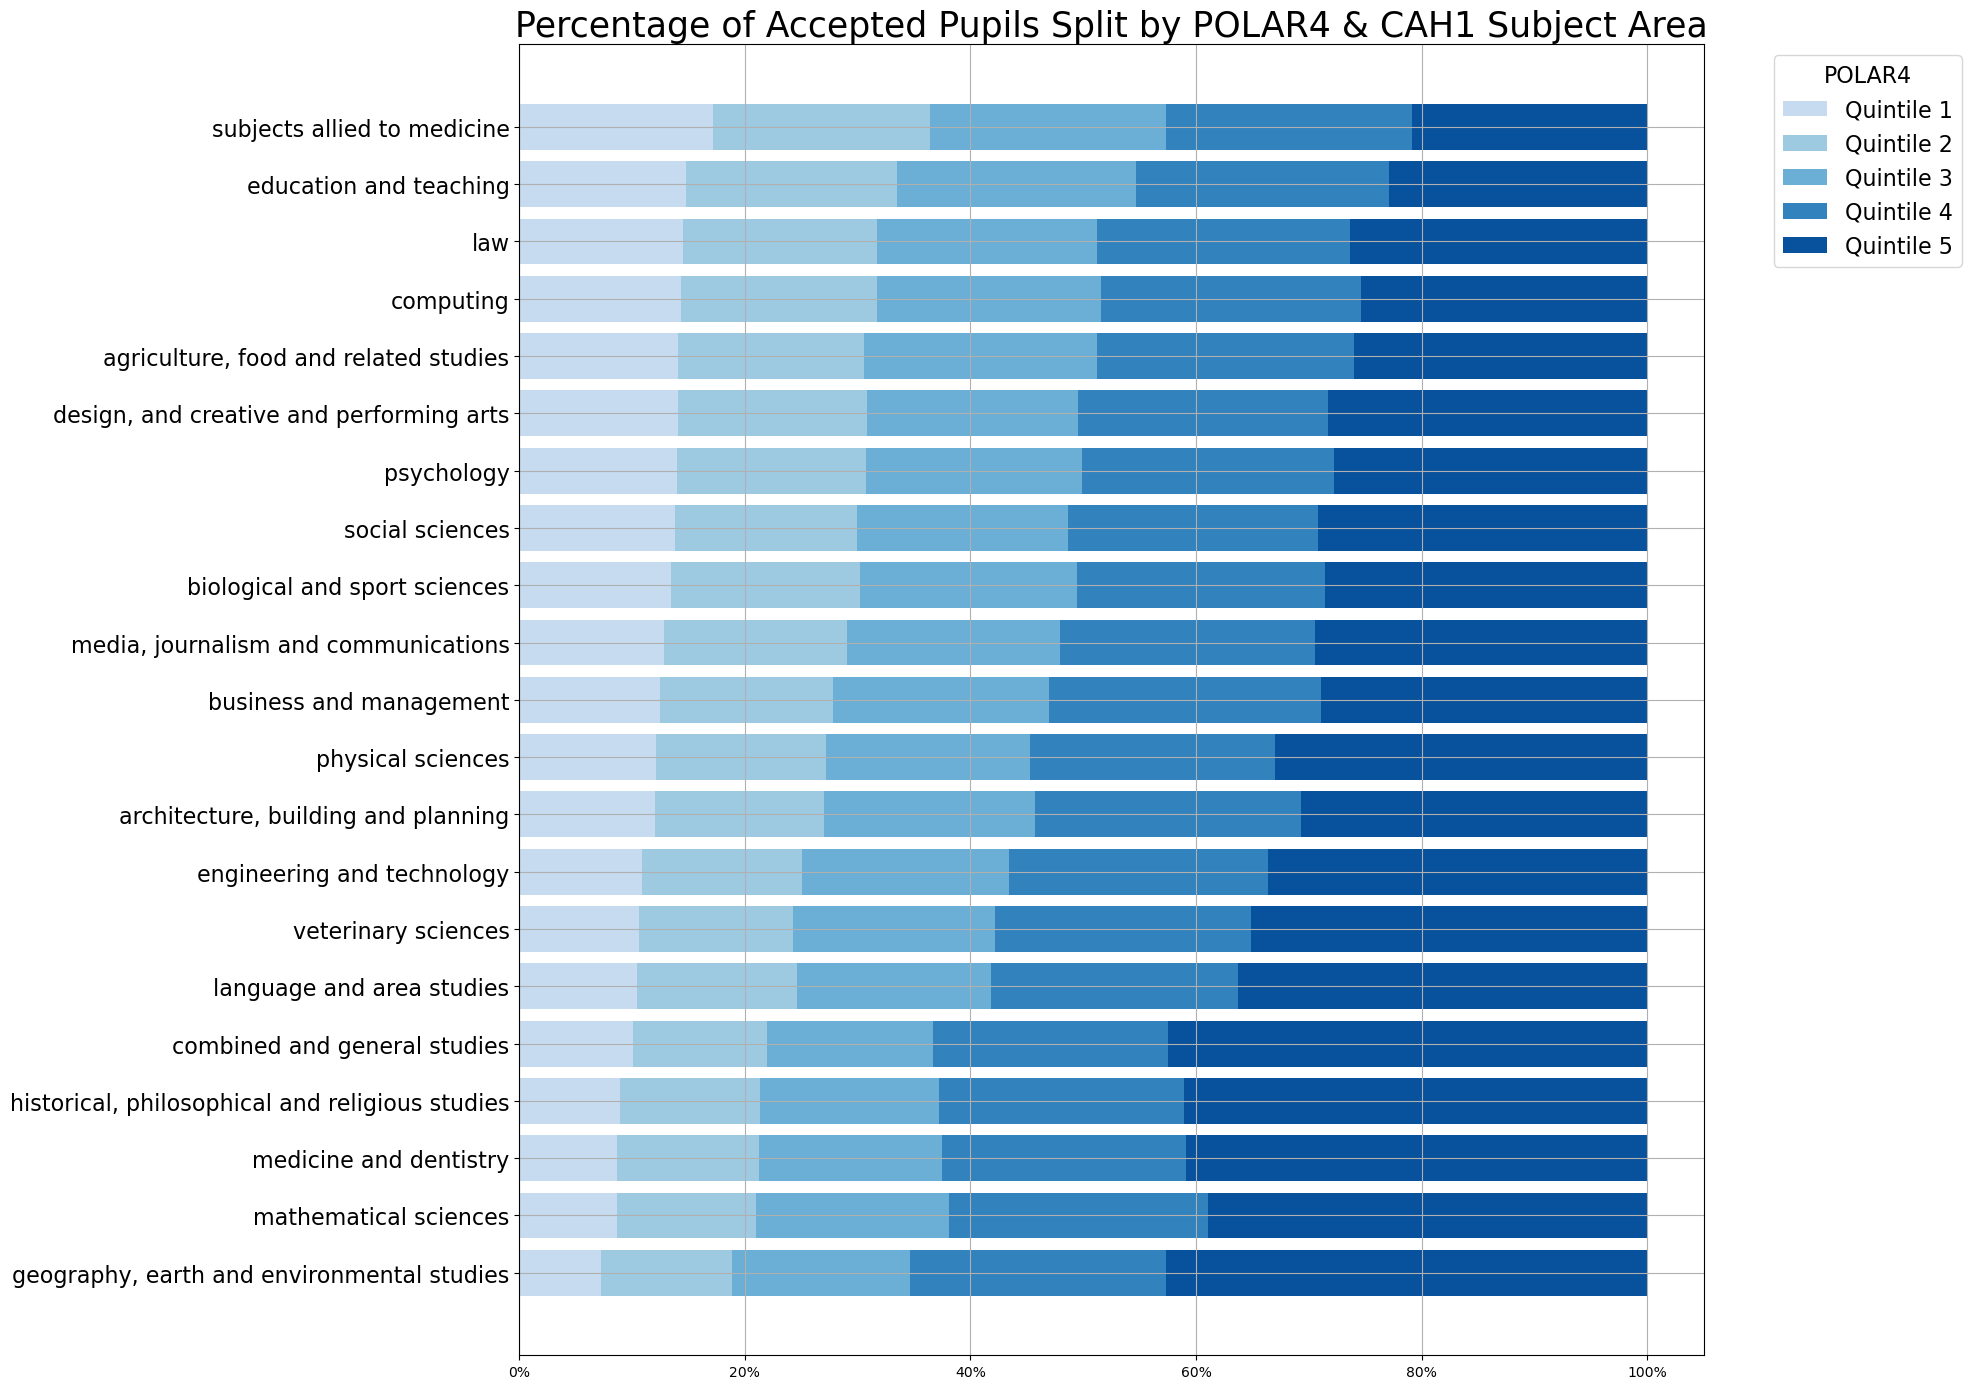

In [511]:
plt.figure(figsize= (20, 14))

plt.barh(y = pivot_table.index, width = pivot_table['Quintile 1'], label = 'Quintile 1', color = '#c6dbef')

plt.barh(y = pivot_table.index, left = pivot_table['Quintile 1'], width = pivot_table['Quintile 2'], label = 'Quintile 2', color = '#9ecae1')

plt.barh(y = pivot_table.index, left = pivot_table['Quintile 1'] + pivot_table['Quintile 2'], label = 'Quintile 3', width = pivot_table['Quintile 3'],color = '#6baed6')

plt.barh(y = pivot_table.index, left = pivot_table['Quintile 1'] + pivot_table['Quintile 2'] + pivot_table['Quintile 3'], width = pivot_table['Quintile 4'], label = 'Quintile 4', color = '#3182bd')

plt.barh(y = pivot_table.index, left = pivot_table['Quintile 1'] + pivot_table['Quintile 2'] + pivot_table['Quintile 3'] + pivot_table['Quintile 4'], width = pivot_table['Quintile 5'], label = 'Quintile 5', color = '#08519c')

plt.legend(title='POLAR4', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, title_fontsize=16)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid()
plt.title('Percentage of Accepted Pupils Split by POLAR4 & Subject Area')
plt.yticks(fontsize=16)
plt.title('Percentage of Accepted Pupils Split by POLAR4 & CAH1 Subject Area', fontsize=25)
plt.tight_layout()
plt.savefig('Accepted Percentage - Ordered.jpeg')


<b><u>Graph Explanation</b></u><br>
The above graph visualises the percentage split of accepted applicants organised by CAH1 subject area and by POLAR4 quintiles.

Important to note that for subjects allied to medicine, the percentage splits are more even across the board. Interestingly, quintile 4 is actually higher than quintile 5 in this subject area

Worth flagging the distinction between low POLAR4 rates in a subject like Geography compared to subjects allied to medicine but being careful not to attempt to infer reasons why. 

### Add Information on this image <!--  -->

In [417]:
ucas_clean_df[ucas_clean_df['Subject group HECoS CAH1'] == '(CAH09) mathematical sciences']['Subject group HECoS CAH3'].value_counts()

Subject group HECoS CAH3
(CAH09-01-01) mathematics             30
(CAH09-01-03) statistics              30
(CAH09-01-02) operational research    27
Name: count, dtype: int64

In [418]:
ucas_clean_df[ucas_clean_df['Subject group HECoS CAH3'] == '(CAH09-01-02) operational research']['POLAR4 Quintile'].value_counts()

POLAR4 Quintile
Quintile 2    6
Quintile 3    6
Quintile 4    6
Quintile 5    6
Quintile 1    3
Name: count, dtype: int64

<b>Notes for the Capstone Project </b><br>
Introduction<br>
Executive Summary<br>
Methodology<br>
Results<br>
Conclusion<br>
Future Work<br>
Submission deadline is 9 September. 


<b>In the following cells, we are creating a new data frame to allow us to figure out and graph the acceptance applicants per quinite per subject</b><br><br>
To do so, we need to create a new df, biv_ucas_year, that includes the year column. We also need to create another df called biv_accept_rate_year that groups by subject and by year. We then merge these and update the biv_ucas_year. 

In [419]:
biv_ucas_year = ucas_clean_df.groupby(['Subject group HECoS CAH1', 'POLAR4 Quintile', 'Year'])['Accepted applicants'].sum()

In [420]:
biv_ucas_year.head()

Subject group HECoS CAH1        POLAR4 Quintile  Year
(CAH01) medicine and dentistry  Quintile 1       2019     790
                                                 2020     945
                                                 2021    1095
                                                 2022     985
                                                 2023     995
Name: Accepted applicants, dtype: int64

In [421]:
biv_accept_rate_year = ucas_clean_df.groupby(['Subject group HECoS CAH1', 'Year'])['Accepted applicants'].sum()

In [422]:
biv_accept_rate_year.head()

Subject group HECoS CAH1        Year
(CAH01) medicine and dentistry  2019    10485
                                2020    11550
                                2021    12135
                                2022    10925
                                2023    11455
Name: Accepted applicants, dtype: int64

In [423]:
biv_ucas_year = biv_ucas_year.reset_index()

In [424]:
biv_ucas_year.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Year,Accepted applicants
0,(CAH01) medicine and dentistry,Quintile 1,2019,790
1,(CAH01) medicine and dentistry,Quintile 1,2020,945
2,(CAH01) medicine and dentistry,Quintile 1,2021,1095
3,(CAH01) medicine and dentistry,Quintile 1,2022,985
4,(CAH01) medicine and dentistry,Quintile 1,2023,995


In [425]:
biv_ucas_year = biv_ucas_year.merge(biv_accept_rate_year, on = ['Subject group HECoS CAH1', 'Year'])

In [426]:
biv_ucas_year.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Year,Accepted applicants_x,Accepted applicants_y
0,(CAH01) medicine and dentistry,Quintile 1,2019,790,10485
1,(CAH01) medicine and dentistry,Quintile 1,2020,945,11550
2,(CAH01) medicine and dentistry,Quintile 1,2021,1095,12135
3,(CAH01) medicine and dentistry,Quintile 1,2022,985,10925
4,(CAH01) medicine and dentistry,Quintile 1,2023,995,11455


In [427]:
biv_ucas_year ['Percentage Accepted'] = biv_ucas_year ['Accepted applicants_x'] / biv_ucas_year ['Accepted applicants_y']

In [428]:
biv_ucas_year.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Year,Accepted applicants_x,Accepted applicants_y,Percentage Accepted
0,(CAH01) medicine and dentistry,Quintile 1,2019,790,10485,0.075346
1,(CAH01) medicine and dentistry,Quintile 1,2020,945,11550,0.081818
2,(CAH01) medicine and dentistry,Quintile 1,2021,1095,12135,0.090235
3,(CAH01) medicine and dentistry,Quintile 1,2022,985,10925,0.090160
4,(CAH01) medicine and dentistry,Quintile 1,2023,995,11455,0.086862


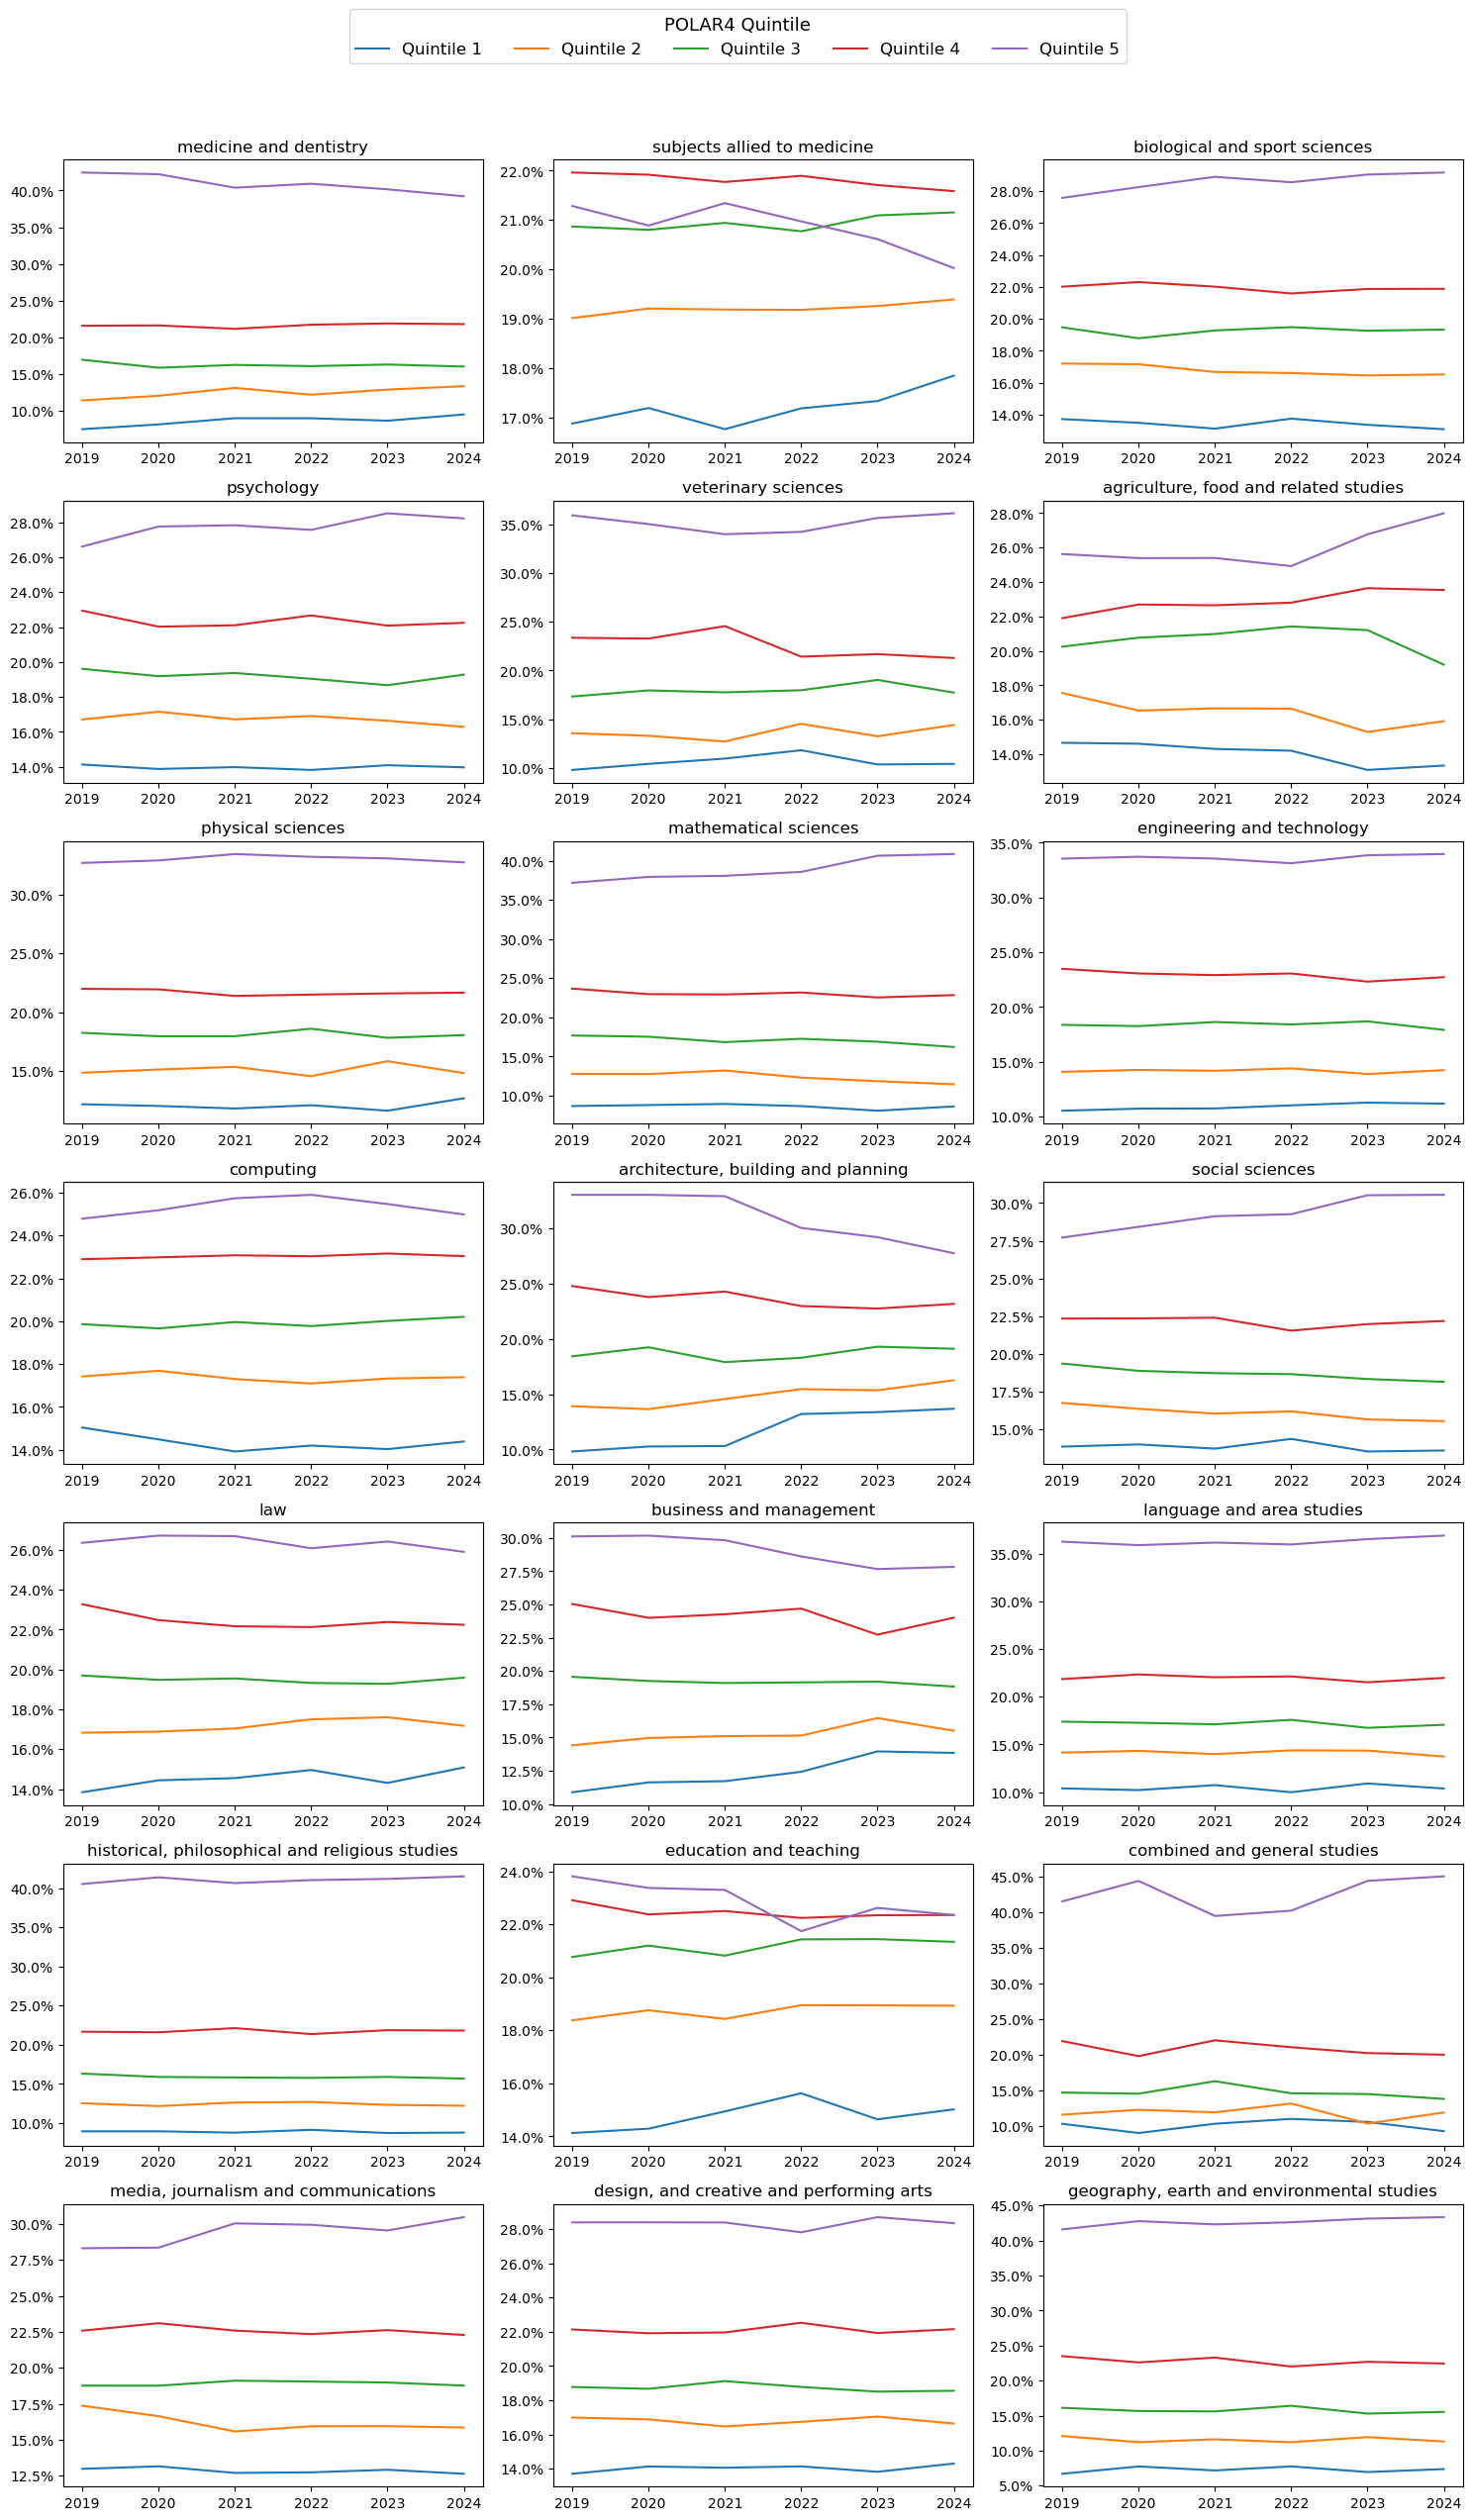

In [517]:
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 25))

for i, subject in enumerate(biv_ucas_year['Subject group HECoS CAH1'].unique()):
    ax = axes[i // 3][i % 3]
    biv_ucas_year_clean = biv_ucas_year [biv_ucas_year['Subject group HECoS CAH1'] == subject]

    for quintile in biv_ucas_year_clean['POLAR4 Quintile'].unique():
        data = biv_ucas_year_clean[biv_ucas_year_clean['POLAR4 Quintile'] == quintile]
        ax.plot(data['Year'], data['Percentage Accepted'], label=quintile)
    ax.set_title(subject.split(')')[1].strip())
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02), fontsize=12, title ='POLAR4 Quintile', title_fontsize=13)
plt.subplots_adjust(top=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('POLAR4 Quintile Acceptances Per Year Per Subject.jpeg', bbox_inches='tight')

Medicine and dentistry — the gap is stark and persistent, with no sign of narrowing over 2019-2024<br>
Subjects allied to medicine — the lines are remarkably close together and the quintiles even cross over, reinforcing our earlier finding<br>
Geography — one of the widest gaps, consistent with what we found in the stacked bar chart<br>
Combined and general studies — very volatile Q5 line, potentia caveat?<br><Br>The overall story is that equity gaps are largely stable over time


## HESA Graduate Outcomes — EDA

In [430]:
hesa_clean_df.columns

Index(['time_period', 'academic_year', 'YAG', 'qualification_level', 'sex',
       'CAH3_code', 'CAH3_subject', 'grads', 'grads_uk', 'unmatched_percent',
       'overseas_percent', 'matched', 'activity_not_captured', 'no_sust_dest',
       'sust_emp_only', 'sust_emp_with_or_without_fs', 'sust_emp_fs_or_both',
       'fs_with_or_without_sust_emp', 'earnings_include', 'earnings_LQ',
       'earnings_median', 'earnings_UQ'],
      dtype='object')

In [431]:
hesa_clean_df.head()

,time_period,academic_year,YAG,qualification_level,sex,CAH3_code,CAH3_subject,grads,grads_uk,unmatched_percent,...,activity_not_captured,no_sust_dest,sust_emp_only,sust_emp_with_or_without_fs,sust_emp_fs_or_both,fs_with_or_without_sust_emp,earnings_include,earnings_LQ,earnings_median,earnings_UQ
0,202324,2019/2020,3 YAG,First-degree,Male,CAH02-06-01,Health sciences (non-specific),735,725,0.4,...,3.4,2,65.6,92.4,94.6,29,465,33300,42500,49000
1,202122,2019/2020,1 YAG,First-degree,Female,CAH02-06-04,Environmental and public health,270,265,0.4,...,1.7,7.2,50,79.2,91.2,41.2,130,16100,21900,27000
2,202324,2021/2022,1 YAG,First-degree,Male,CAH02-05-01,Medical technology,280,280,0.7,...,2.5,3.2,85.6,94.2,94.2,8.7,235,31100,35100,41400
3,202324,2021/2022,1 YAG,First-degree,Female,CAH02-04-04,Midwifery,1910,1895,0.4,...,1.4,2.5,87.8,95.6,96.1,8.3,1655,31500,36600,42100
4,202324,2021/2022,1 YAG,First-degree,Female,CAH03-01-06,Zoology,725,695,0.8,...,1.3,9.4,61.7,81.1,89.3,27.6,410,15400,21200,24900


In [432]:
ucas_clean_df['Subject group HECoS CAH3'].head()

0    (CAH25-01-03) design studies
1    (CAH25-01-03) design studies
2    (CAH25-01-03) design studies
3    (CAH25-01-03) design studies
4    (CAH25-01-03) design studies
Name: Subject group HECoS CAH3, dtype: object

In [433]:
hesa_clean_df['CAH3_code'].head()

0    CAH02-06-01
1    CAH02-06-04
2    CAH02-05-01
3    CAH02-04-04
4    CAH03-01-06
Name: CAH3_code, dtype: object

## Performing merge on the CAH3 codes in the UCAS and HESA datasets<BR>

We need to split the strings to ensure the codes up. On the UCAS dataset, we need to drop the subject from the CAH3 column. We can then match this up to the HESA dataset, despite the subject names not being in the CAH3  column. This is because there is a separate subject name column in the HESA dataset. 

In [434]:
ucas_clean_df['CAH3_code'] = ucas_clean_df['Subject group HECoS CAH3'].str.split(')').str[0].str.replace('(', '', regex=False)

In [435]:
ucas_clean_df['CAH3_code'].head()

0    CAH25-01-03
1    CAH25-01-03
2    CAH25-01-03
3    CAH25-01-03
4    CAH25-01-03
Name: CAH3_code, dtype: object

In [436]:
ucas_codes = set(ucas_clean_df['CAH3_code'].unique())
hesa_codes = set(hesa_clean_df['CAH3_code'].unique())
print(f'UCAS unique codes: {len(ucas_codes)}')
print(f'HESA unique codes: {len(hesa_codes)}')
print(f'Codes in both: {len(ucas_codes & hesa_codes)}')
print(f'UCAS codes not in HESA: {len(ucas_codes - hesa_codes)}')

UCAS unique codes: 164
HESA unique codes: 164
Codes in both: 162
UCAS codes not in HESA: 2


In [437]:
print(ucas_codes - hesa_codes)

{'CAH19-02-03', 'CAH19-02-02'}


In [438]:
ucas_clean_df[ucas_clean_df['CAH3_code'].isin(['CAH19-02-03', 'CAH19-02-02'])]['Subject group HECoS CAH3'].unique()

array(['(CAH19-02-03) Welsh studies', '(CAH19-02-02) Gaelic studies'],
      dtype=object)

There were only two subjects where the CAH3 codes didn't match up - Welsh and Gaelic Studies. These are niche subjects. This is file and is not a significant loss for our analysis. These will need to be removed from the dataset.

In [439]:
ucas_hesa_merge = ucas_clean_df.merge(hesa_clean_df, on='CAH3_code')

In [440]:
ucas_hesa_merge.head()

,Year,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Main scheme applicant,Main scheme application,Accepted applicants,CAH3_code,time_period,academic_year,...,activity_not_captured,no_sust_dest,sust_emp_only,sust_emp_with_or_without_fs,sust_emp_fs_or_both,fs_with_or_without_sust_emp,earnings_include,earnings_LQ,earnings_median,earnings_UQ
0,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03,202122,2019/2020,...,3.1,10.3,73.3,83.4,86.6,13.3,5510,13100,18200,21900
1,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03,202324,2021/2022,...,3.7,12.2,74.9,81.2,84.1,9.2,5175,15700,22000,25300
2,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03,202324,2021/2022,...,5.5,12.2,73.8,79.6,82.3,8.5,1935,16100,22700,26400
3,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03,202223,2020/2021,...,4.6,12,73.9,79.9,83.4,9.5,2180,16800,21500,25600
4,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03,202122,2019/2020,...,4.3,12.8,72.6,79.2,82.8,10.3,2115,13100,18600,23000


In [441]:
len(ucas_hesa_merge)

37957

In [442]:
ucas_hesa_merge.columns

Index(['Year', 'Subject group HECoS CAH1', 'Subject group HECoS CAH3',
       'POLAR4 Quintile', 'Main scheme applicant', 'Main scheme application',
       'Accepted applicants', 'CAH3_code', 'time_period', 'academic_year',
       'YAG', 'qualification_level', 'sex', 'CAH3_subject', 'grads',
       'grads_uk', 'unmatched_percent', 'overseas_percent', 'matched',
       'activity_not_captured', 'no_sust_dest', 'sust_emp_only',
       'sust_emp_with_or_without_fs', 'sust_emp_fs_or_both',
       'fs_with_or_without_sust_emp', 'earnings_include', 'earnings_LQ',
       'earnings_median', 'earnings_UQ'],
      dtype='object')

In [443]:
hesa_clean_df.head()

,time_period,academic_year,YAG,qualification_level,sex,CAH3_code,CAH3_subject,grads,grads_uk,unmatched_percent,...,activity_not_captured,no_sust_dest,sust_emp_only,sust_emp_with_or_without_fs,sust_emp_fs_or_both,fs_with_or_without_sust_emp,earnings_include,earnings_LQ,earnings_median,earnings_UQ
0,202324,2019/2020,3 YAG,First-degree,Male,CAH02-06-01,Health sciences (non-specific),735,725,0.4,...,3.4,2,65.6,92.4,94.6,29,465,33300,42500,49000
1,202122,2019/2020,1 YAG,First-degree,Female,CAH02-06-04,Environmental and public health,270,265,0.4,...,1.7,7.2,50,79.2,91.2,41.2,130,16100,21900,27000
2,202324,2021/2022,1 YAG,First-degree,Male,CAH02-05-01,Medical technology,280,280,0.7,...,2.5,3.2,85.6,94.2,94.2,8.7,235,31100,35100,41400
3,202324,2021/2022,1 YAG,First-degree,Female,CAH02-04-04,Midwifery,1910,1895,0.4,...,1.4,2.5,87.8,95.6,96.1,8.3,1655,31500,36600,42100
4,202324,2021/2022,1 YAG,First-degree,Female,CAH03-01-06,Zoology,725,695,0.8,...,1.3,9.4,61.7,81.1,89.3,27.6,410,15400,21200,24900


HESA outcomes are averaged across available academic years (2019/20–2021/22) and linked to UCAS data at subject level. Year-level alignment between application cohorts and graduate outcome cohorts is outside the scope of this analysis but is acknowledged as a limitation.

At this stage, I now need to consider how to aggregate the data. This means that we need to try to match up the data in the UCAS dataset with the HESA dataset. Unfortunately, this is proving hard to achieve, as the years don't match up properly. Instead, what we will do is aggregate and average out the HESA outcomes to one row per CAH3 subject. To do so, we will group by CAH3_code, YA and academic year. We also need to merge the sex column so as not to disinguish between them. 

The challenge that we now have is that we have a "c" value in the earnings columns of the HESA dataset. Essentially, this is a value that suppresses some of the values to preserve anonymity, potentially because they could identify people from low populations What we need to do is convert the earnings columns of the HESA dataset to NaN values so thast we can calculate the averages. These are stored as object data types, which will mean that we won't be able to calculate the averages:

<b>Summary</b>
According to the HESA website:<br>
'c' (Confidential / Suppressed): Indicates a small number that has been suppressed to preserve anonymity or prevent the identification of an individual. Under the HESA Rounding and Suppression Strategy, data points involving very low populations (such as percentages based on fewer than 22.5 people or averages based on 7 or fewer people) are hidden or modified for security.

z (Not Applicable): Indicates that the data field or category is not applicable to that specific cohort, institution, or column. For instance, a cell is marked z if a specific course or demographic category is not offered or relevant to the group being measured

In [444]:
# Suppress the values in the earnings_median column
hesa_clean_df['earnings_median'] = hesa_clean_df['earnings_median'].replace({'c': np.nan, 'z': np.nan})

hesa_clean_df['earnings_median'] = hesa_clean_df['earnings_median'].astype(float)



In [445]:
# Suppress the values in the earnings_LQ (lower quartile) column
hesa_clean_df['earnings_LQ'] = hesa_clean_df['earnings_LQ'].replace({'c': np.nan, 'z': np.nan})

hesa_clean_df['earnings_LQ'] = hesa_clean_df['earnings_LQ'].astype(float)



In [446]:
# Suppress the values in the earnings_uq (upper quartile) column
hesa_clean_df['earnings_UQ'] = hesa_clean_df['earnings_UQ'].replace({'c': np.nan, 'z': np.nan})

hesa_clean_df['earnings_UQ'] = hesa_clean_df['earnings_UQ'].astype(float)



In [447]:
hesa_clean_df[['earnings_LQ', 'earnings_median', 'earnings_UQ']].dtypes

earnings_LQ        float64
earnings_median    float64
earnings_UQ        float64
dtype: object

The code below has will group and average the earnings by CAH3 subject and YAG. I initially included sex in here but this would make the merge with the UCAS dataset challenging, as the data is not split out by sex.  

In [448]:
hesa_agg = hesa_clean_df.groupby(['CAH3_code', 'YAG'])[['earnings_median', 'earnings_LQ', 'earnings_UQ']].mean()

In [449]:
hesa_agg.head()

earnings_median   earnings_LQ   earnings_UQ
CAH3_code   YAG                                               
CAH01-01-01 1 YAG     24800.000000  18866.666667  31100.000000
            3 YAG     38050.000000  27800.000000  45400.000000
CAH01-01-02 1 YAG     41416.666667  38366.666667  46916.666667
            3 YAG     52000.000000  42800.000000  61650.000000
CAH01-01-03 1 YAG     30666.666667  27400.000000  33966.666667

In [450]:
hesa_agg = hesa_agg.reset_index()
print(len(hesa_agg))

328


In [451]:
ucas_clean_df.head()

,Year,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Main scheme applicant,Main scheme application,Accepted applicants,CAH3_code
0,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03
1,2020,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2120,CAH25-01-03
2,2021,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2070,CAH25-01-03
3,2022,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2100,CAH25-01-03
4,2023,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03


In this section, we attempt to merge the UCAS data with the HESA dataset. We do this by grouping by CAH3_code, CAH3 subject, CAH1 subject and POLAR4 quintile. 

First, we need to aggregate the ucas_clean_df. 

In [452]:
ucas_agg = ucas_clean_df.groupby(['CAH3_code', 'Subject group HECoS CAH1', 'Subject group HECoS CAH3', 'POLAR4 Quintile'])['Accepted applicants'].sum()

In [453]:
ucas_agg.head()

CAH3_code    Subject group HECoS CAH1        Subject group HECoS CAH3                       POLAR4 Quintile
CAH01-01-01  (CAH01) medicine and dentistry  (CAH01-01-01) medical sciences (non-specific)  Quintile 1         300
                                                                                            Quintile 2         365
                                                                                            Quintile 3         475
                                                                                            Quintile 4         485
                                                                                            Quintile 5         700
Name: Accepted applicants, dtype: int64

In [454]:
ucas_agg = ucas_agg.reset_index()
print(len(ucas_agg))

812


In [455]:
ucas_hesa_merge = ucas_agg.merge(hesa_agg, on = 'CAH3_code')

In [456]:
type(ucas_hesa_merge)

pandas.core.frame.DataFrame

In [457]:
result = ucas_agg.merge(hesa_agg, on='CAH3_code')
type(result)

pandas.core.frame.DataFrame

In [458]:
ucas_hesa_merge.head()

,CAH3_code,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Accepted applicants,YAG,earnings_median,earnings_LQ,earnings_UQ
0,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,1 YAG,24800.0,18866.666667,31100.0
1,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,3 YAG,38050.0,27800.000000,45400.0
2,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,1 YAG,24800.0,18866.666667,31100.0
3,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,3 YAG,38050.0,27800.000000,45400.0
4,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 3,475,1 YAG,24800.0,18866.666667,31100.0


In [459]:
len(ucas_hesa_merge)

1606

One of the things identified at this stage is that it for the purpose of visualisation, it would be helpful to have a bivariate value here where we compare the accepted applicants by the total number of applicants. As such, we will conduct a merge with the ucas_hesa_merge dataset with the accepted applicants table. 

In [460]:
biv_hesa_merge = ucas_hesa_merge.groupby(['Subject group HECoS CAH3', 'CAH3_code'])['Accepted applicants'].sum()

In [461]:
biv_hesa_merge.head()

Subject group HECoS CAH3                       CAH3_code  
(CAH01-01-01) medical sciences (non-specific)  CAH01-01-01      4650
(CAH01-01-02) medicine (non-specific)          CAH01-01-02    113070
(CAH01-01-03) medicine by specialism           CAH01-01-03      2750
(CAH01-01-04) dentistry                        CAH01-01-04     16550
(CAH02-02-01) pharmacology                     CAH02-02-01     14750
Name: Accepted applicants, dtype: int64

In [462]:
ucas_clean_df.head()

,Year,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Main scheme applicant,Main scheme application,Accepted applicants,CAH3_code
0,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03
1,2020,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2120,CAH25-01-03
2,2021,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2070,CAH25-01-03
3,2022,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2100,CAH25-01-03
4,2023,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,All,All,2050,CAH25-01-03


In [463]:
biv_hesa_merge = biv_hesa_merge.reset_index()

In [464]:
biv_hesa_merge.head()

,Subject group HECoS CAH3,CAH3_code,Accepted applicants
0,(CAH01-01-01) medical sciences (non-specific),CAH01-01-01,4650
1,(CAH01-01-02) medicine (non-specific),CAH01-01-02,113070
2,(CAH01-01-03) medicine by specialism,CAH01-01-03,2750
3,(CAH01-01-04) dentistry,CAH01-01-04,16550
4,(CAH02-02-01) pharmacology,CAH02-02-01,14750


In [465]:
totals = biv_hesa_merge.set_index('CAH3_code')['Accepted applicants']

In [466]:
totals.head()

CAH3_code
CAH01-01-01      4650
CAH01-01-02    113070
CAH01-01-03      2750
CAH01-01-04     16550
CAH02-02-01     14750
Name: Accepted applicants, dtype: int64

In [467]:
ucas_hesa_merge['Accepted share'] = ucas_hesa_merge['Accepted applicants'] / ucas_hesa_merge['CAH3_code'].map(totals)

In [468]:
ucas_hesa_merge[['CAH3_code', 'POLAR4 Quintile', 'Accepted share', 'earnings_median']].head(10)

,CAH3_code,POLAR4 Quintile,Accepted share,earnings_median
0,CAH01-01-01,Quintile 1,0.064516,24800.0
1,CAH01-01-01,Quintile 1,0.064516,38050.0
2,CAH01-01-01,Quintile 2,0.078495,24800.0
3,CAH01-01-01,Quintile 2,0.078495,38050.0
4,CAH01-01-01,Quintile 3,0.102151,24800.0
5,CAH01-01-01,Quintile 3,0.102151,38050.0
6,CAH01-01-01,Quintile 4,0.104301,24800.0
7,CAH01-01-01,Quintile 4,0.104301,38050.0
8,CAH01-01-01,Quintile 5,0.150538,24800.0
9,CAH01-01-01,Quintile 5,0.150538,38050.0


I am getting duplicate rows here, as it is showing both 1YAG and 3YAG numbers for earnings 1 or 3 years after graduation. For the purpose of visualisation and analysis, we are going to filter the rows to only focus on 3 years after graduation earnings to give a more settled picture of earnings. 

In [469]:
ucas_hesa_merge.head()

,CAH3_code,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Accepted applicants,YAG,earnings_median,earnings_LQ,earnings_UQ,Accepted share
0,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,1 YAG,24800.0,18866.666667,31100.0,0.064516
1,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,3 YAG,38050.0,27800.000000,45400.0,0.064516
2,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,1 YAG,24800.0,18866.666667,31100.0,0.078495
3,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,3 YAG,38050.0,27800.000000,45400.0,0.078495
4,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 3,475,1 YAG,24800.0,18866.666667,31100.0,0.102151


In [470]:
ucas_hesa_3yag = ucas_hesa_merge[ucas_hesa_merge['YAG'].isin(['3 YAG'])]



The code below confirms our length of 803, which is half of the 1606 we saw earlier in the merged dataset, confirming that we have removed half of the lines. We previously had 1YAG and 3YAG, so by filtering 1YAG, we have removed half of the lines. 

In [471]:
len(ucas_hesa_3yag)

803

## Let's visualise our merged dataset! 

''

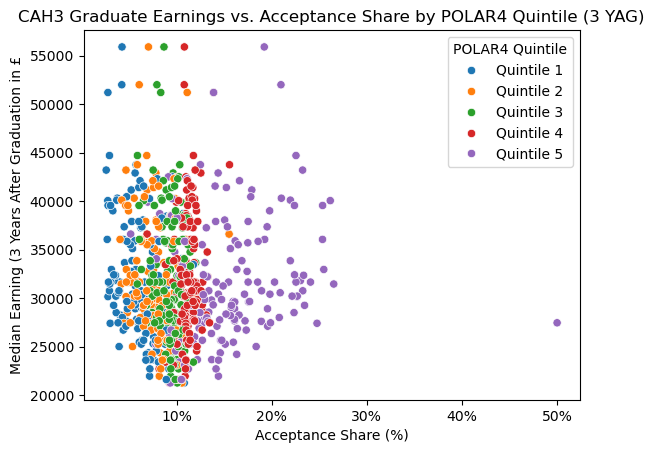

In [472]:


plot = sns.scatterplot(data = ucas_hesa_3yag, 
                x = 'Accepted share', 
                y = 'earnings_median',
                hue = 'POLAR4 Quintile')

plot.set_title('CAH3 Graduate Earnings vs. Acceptance Share by POLAR4 Quintile (3 YAG)')

plot.set_xlabel('Acceptance Share (%)')

plot.set_ylabel('Median Earning (3 Years After Graduation in £')

plot.xaxis.set_major_formatter(PercentFormatter(1.0))

plt.savefig('CAH3 Graduate Earnings Table.pdf')
;

The scatter plot shows acceptance share by POLAR4 quintile on the x-axis against median graduate earnings at 3 YAG on the y-axis. Because HESA graduate outcomes data is not disaggregated by POLAR4 quintile, all five quintiles within a subject share the same earnings value. The chart therefore illustrates the relationship between a subject's overall earnings outcomes and how equitably its places are distributed across quintiles, rather than comparing earnings by socioeconomic background directly.<Br><br>
Contrary to my initial hypothesis, the scatter plot does not reveal a clear relationship between a subject's POLAR4 equty profile and its graduate earnings outcomes. Subjects with a low Q1 acceptance share are distributed across the full range of earnings, suggesting that inequitable access is not confined to high-earning subjects alone. <br><BR>It must be remembered that the above chart is organised by CAH3 levels, which are more granular that CAH1 - there are 164 CAH3 subjects, as opposed to 21 CAH1 'umbrella' subjects. It would be correct to run a scatter plot analysis on  the CAH1 subjects to see whether an underlying pattern is more visible.<br><BR>To do so, we need to create a new aggregate dataframe for CAH1 on the ucas_hesa_3yag dataframe.  

In [473]:
ucas_hesa_merge.head()

,CAH3_code,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Accepted applicants,YAG,earnings_median,earnings_LQ,earnings_UQ,Accepted share
0,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,1 YAG,24800.0,18866.666667,31100.0,0.064516
1,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,3 YAG,38050.0,27800.000000,45400.0,0.064516
2,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,1 YAG,24800.0,18866.666667,31100.0,0.078495
3,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,3 YAG,38050.0,27800.000000,45400.0,0.078495
4,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 3,475,1 YAG,24800.0,18866.666667,31100.0,0.102151


In [474]:
cah1_hesa_merge = ucas_hesa_3yag.groupby(['Subject group HECoS CAH1', 'POLAR4 Quintile'])['Accepted applicants'].sum()

In [475]:
cah1_hesa_merge.head()

Subject group HECoS CAH1        POLAR4 Quintile
(CAH01) medicine and dentistry  Quintile 1          5950
                                Quintile 2          8605
                                Quintile 3         11140
                                Quintile 4         14830
                                Quintile 5         27985
Name: Accepted applicants, dtype: int64

In [476]:
cah1_hesa_merge = cah1_hesa_merge.reset_index()

In [477]:
cah1_accepted = ucas_hesa_3yag.groupby(['Subject group HECoS CAH1'])['Accepted applicants'].sum()

In [478]:
cah1_hesa_merge['Accepted share'] = cah1_hesa_merge['Accepted applicants'] / cah1_hesa_merge['Subject group HECoS CAH1'].map(cah1_accepted)

In [479]:
cah1_hesa_merge.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Accepted applicants,Accepted share
0,(CAH01) medicine and dentistry,Quintile 1,5950,0.086849
1,(CAH01) medicine and dentistry,Quintile 2,8605,0.125602
2,(CAH01) medicine and dentistry,Quintile 3,11140,0.162604
3,(CAH01) medicine and dentistry,Quintile 4,14830,0.216465
4,(CAH01) medicine and dentistry,Quintile 5,27985,0.408481


In [480]:
ucas_hesa_3yag.head()

,CAH3_code,Subject group HECoS CAH1,Subject group HECoS CAH3,POLAR4 Quintile,Accepted applicants,YAG,earnings_median,earnings_LQ,earnings_UQ,Accepted share
1,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 1,300,3 YAG,38050.0,27800.0,45400.0,0.064516
3,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 2,365,3 YAG,38050.0,27800.0,45400.0,0.078495
5,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 3,475,3 YAG,38050.0,27800.0,45400.0,0.102151
7,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 4,485,3 YAG,38050.0,27800.0,45400.0,0.104301
9,CAH01-01-01,(CAH01) medicine and dentistry,(CAH01-01-01) medical sciences (non-specific),Quintile 5,700,3 YAG,38050.0,27800.0,45400.0,0.150538


In [481]:
cah1_hesa_agg = ucas_hesa_3yag.groupby(['Subject group HECoS CAH1'])['earnings_median'].mean()

In [482]:
cah1_hesa_agg.head()

Subject group HECoS CAH1
(CAH01) medicine and dentistry           47212.500000
(CAH02) subjects allied to medicine      36363.636364
(CAH03) biological and sport sciences    28600.000000
(CAH04) psychology                       26300.000000
(CAH05) veterinary sciences              34050.000000
Name: earnings_median, dtype: float64

In [483]:
cah1_hesa_merge['earnings_median'] = cah1_hesa_merge['Subject group HECoS CAH1'].map(cah1_hesa_agg)

In [484]:
cah1_hesa_merge.head()

,Subject group HECoS CAH1,POLAR4 Quintile,Accepted applicants,Accepted share,earnings_median
0,(CAH01) medicine and dentistry,Quintile 1,5950,0.086849,47212.5
1,(CAH01) medicine and dentistry,Quintile 2,8605,0.125602,47212.5
2,(CAH01) medicine and dentistry,Quintile 3,11140,0.162604,47212.5
3,(CAH01) medicine and dentistry,Quintile 4,14830,0.216465,47212.5
4,(CAH01) medicine and dentistry,Quintile 5,27985,0.408481,47212.5


''

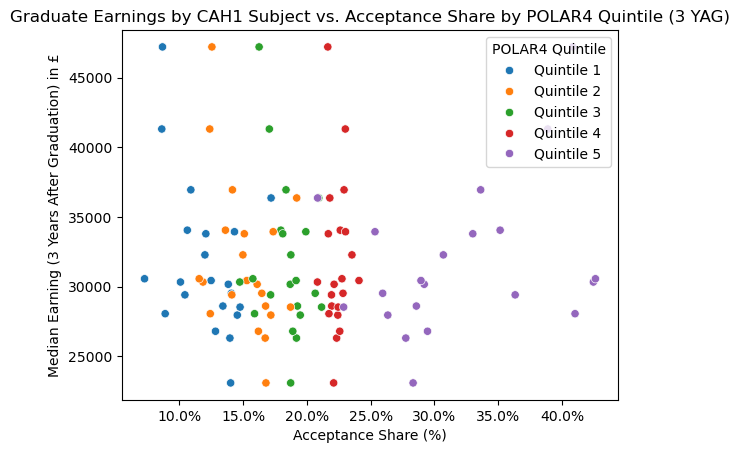

In [518]:


plot = sns.scatterplot(data = cah1_hesa_merge,

                x = 'Accepted share', 

                y = 'earnings_median',

                hue = 'POLAR4 Quintile')

plot.set_title('Graduate Earnings by CAH1 Subject vs. Acceptance Share by POLAR4 Quintile (3 YAG)')

plot.set_xlabel('Acceptance Share (%)')

plot.set_ylabel('Median Earning (3 Years After Graduation) in £')

plot.xaxis.set_major_formatter(PercentFormatter(1.0))

plt.savefig('CAH1 Graduate Earnings Table.pdf')

;

In [486]:
cah1_hesa_merge.groupby('Subject group HECoS CAH1')['earnings_median'].mean().sort_values(ascending=False).head(26)

Subject group HECoS CAH1
(CAH01) medicine and dentistry                             47212.500000
(CAH09) mathematical sciences                              41316.666667
(CAH10) engineering and technology                         36946.666667
(CAH02) subjects allied to medicine                        36363.636364
(CAH05) veterinary sciences                                34050.000000
(CAH11) computing                                          33937.500000
(CAH07) physical sciences                                  33791.666667
(CAH13) architecture, building and planning                32275.000000
(CAH26) geography, earth and environmental studies         30560.000000
(CAH17) business and management                            30431.707317
(CAH23) combined and general studies                       30325.000000
(CAH15) social sciences                                    30163.636364
(CAH06) agriculture, food and related studies              29516.666667
(CAH19) language and area studies      

By grouping the subjects into their umbrella CAH1 subject groupings, we notice an interesting pattern. Whilst medicine is the top earner (something we expected), Mathematical sciences comes in second and Engineering comes in third. This is an interesting finding, as our previous analysis shows that Mathematical Sciences had one of the lowest Q1 POLAR4 acceptance rates that we saw in the stacked bar chart but it also has one of the most powerful earning potentials, thus providing a powerful example of compounding disadvantage - essentially, that disadvantaged students are underrepresented in a subject that delivers one of the highest median earnings outcomes 3 years after graduation. 

I'm not too happy with the data visualisation above, as we can't identify the individual subject areas. I am therefore going to recreate out stacked bar chart and present it in a different format where I sort the values by median earnings and then add labels for the median earnings too. 

In [487]:
pivot_table_hesa = pd.pivot_table(cah1_hesa_merge, 
                   index = 'Subject group HECoS CAH1', 
                   columns = 'POLAR4 Quintile',
                  values = 'Accepted share')

In [488]:
pivot_table_hesa.head()

POLAR4 Quintile,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5
Subject group HECoS CAH1,,,,,
(CAH01) medicine and dentistry,0.086849,0.125602,0.162604,0.216465,0.408481
(CAH02) subjects allied to medicine,0.171988,0.192078,0.209401,0.218043,0.208490
(CAH03) biological and sport sciences,0.134211,0.167709,0.192667,0.219526,0.285887
(CAH04) psychology,0.139717,0.167373,0.191884,0.223404,0.277622
(CAH05) veterinary sciences,0.106325,0.136205,0.179666,0.226232,0.351572


In [489]:
earnings_order = cah1_hesa_agg.sort_values().index
pivot_table_hesa = pivot_table_hesa.loc[earnings_order]

In [490]:
pivot_table_hesa.head()

POLAR4 Quintile,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5
Subject group HECoS CAH1,,,,,
"(CAH25) design, and creative and performing arts",0.140287,0.167972,0.187360,0.221048,0.283334
(CAH04) psychology,0.139717,0.167373,0.191884,0.223404,0.277622
"(CAH24) media, journalism and communications",0.128413,0.162061,0.189029,0.225850,0.294648
(CAH16) law,0.145505,0.171810,0.194862,0.224310,0.263514
"(CAH20) historical, philosophical and religious studies",0.088963,0.124318,0.159043,0.217373,0.410302


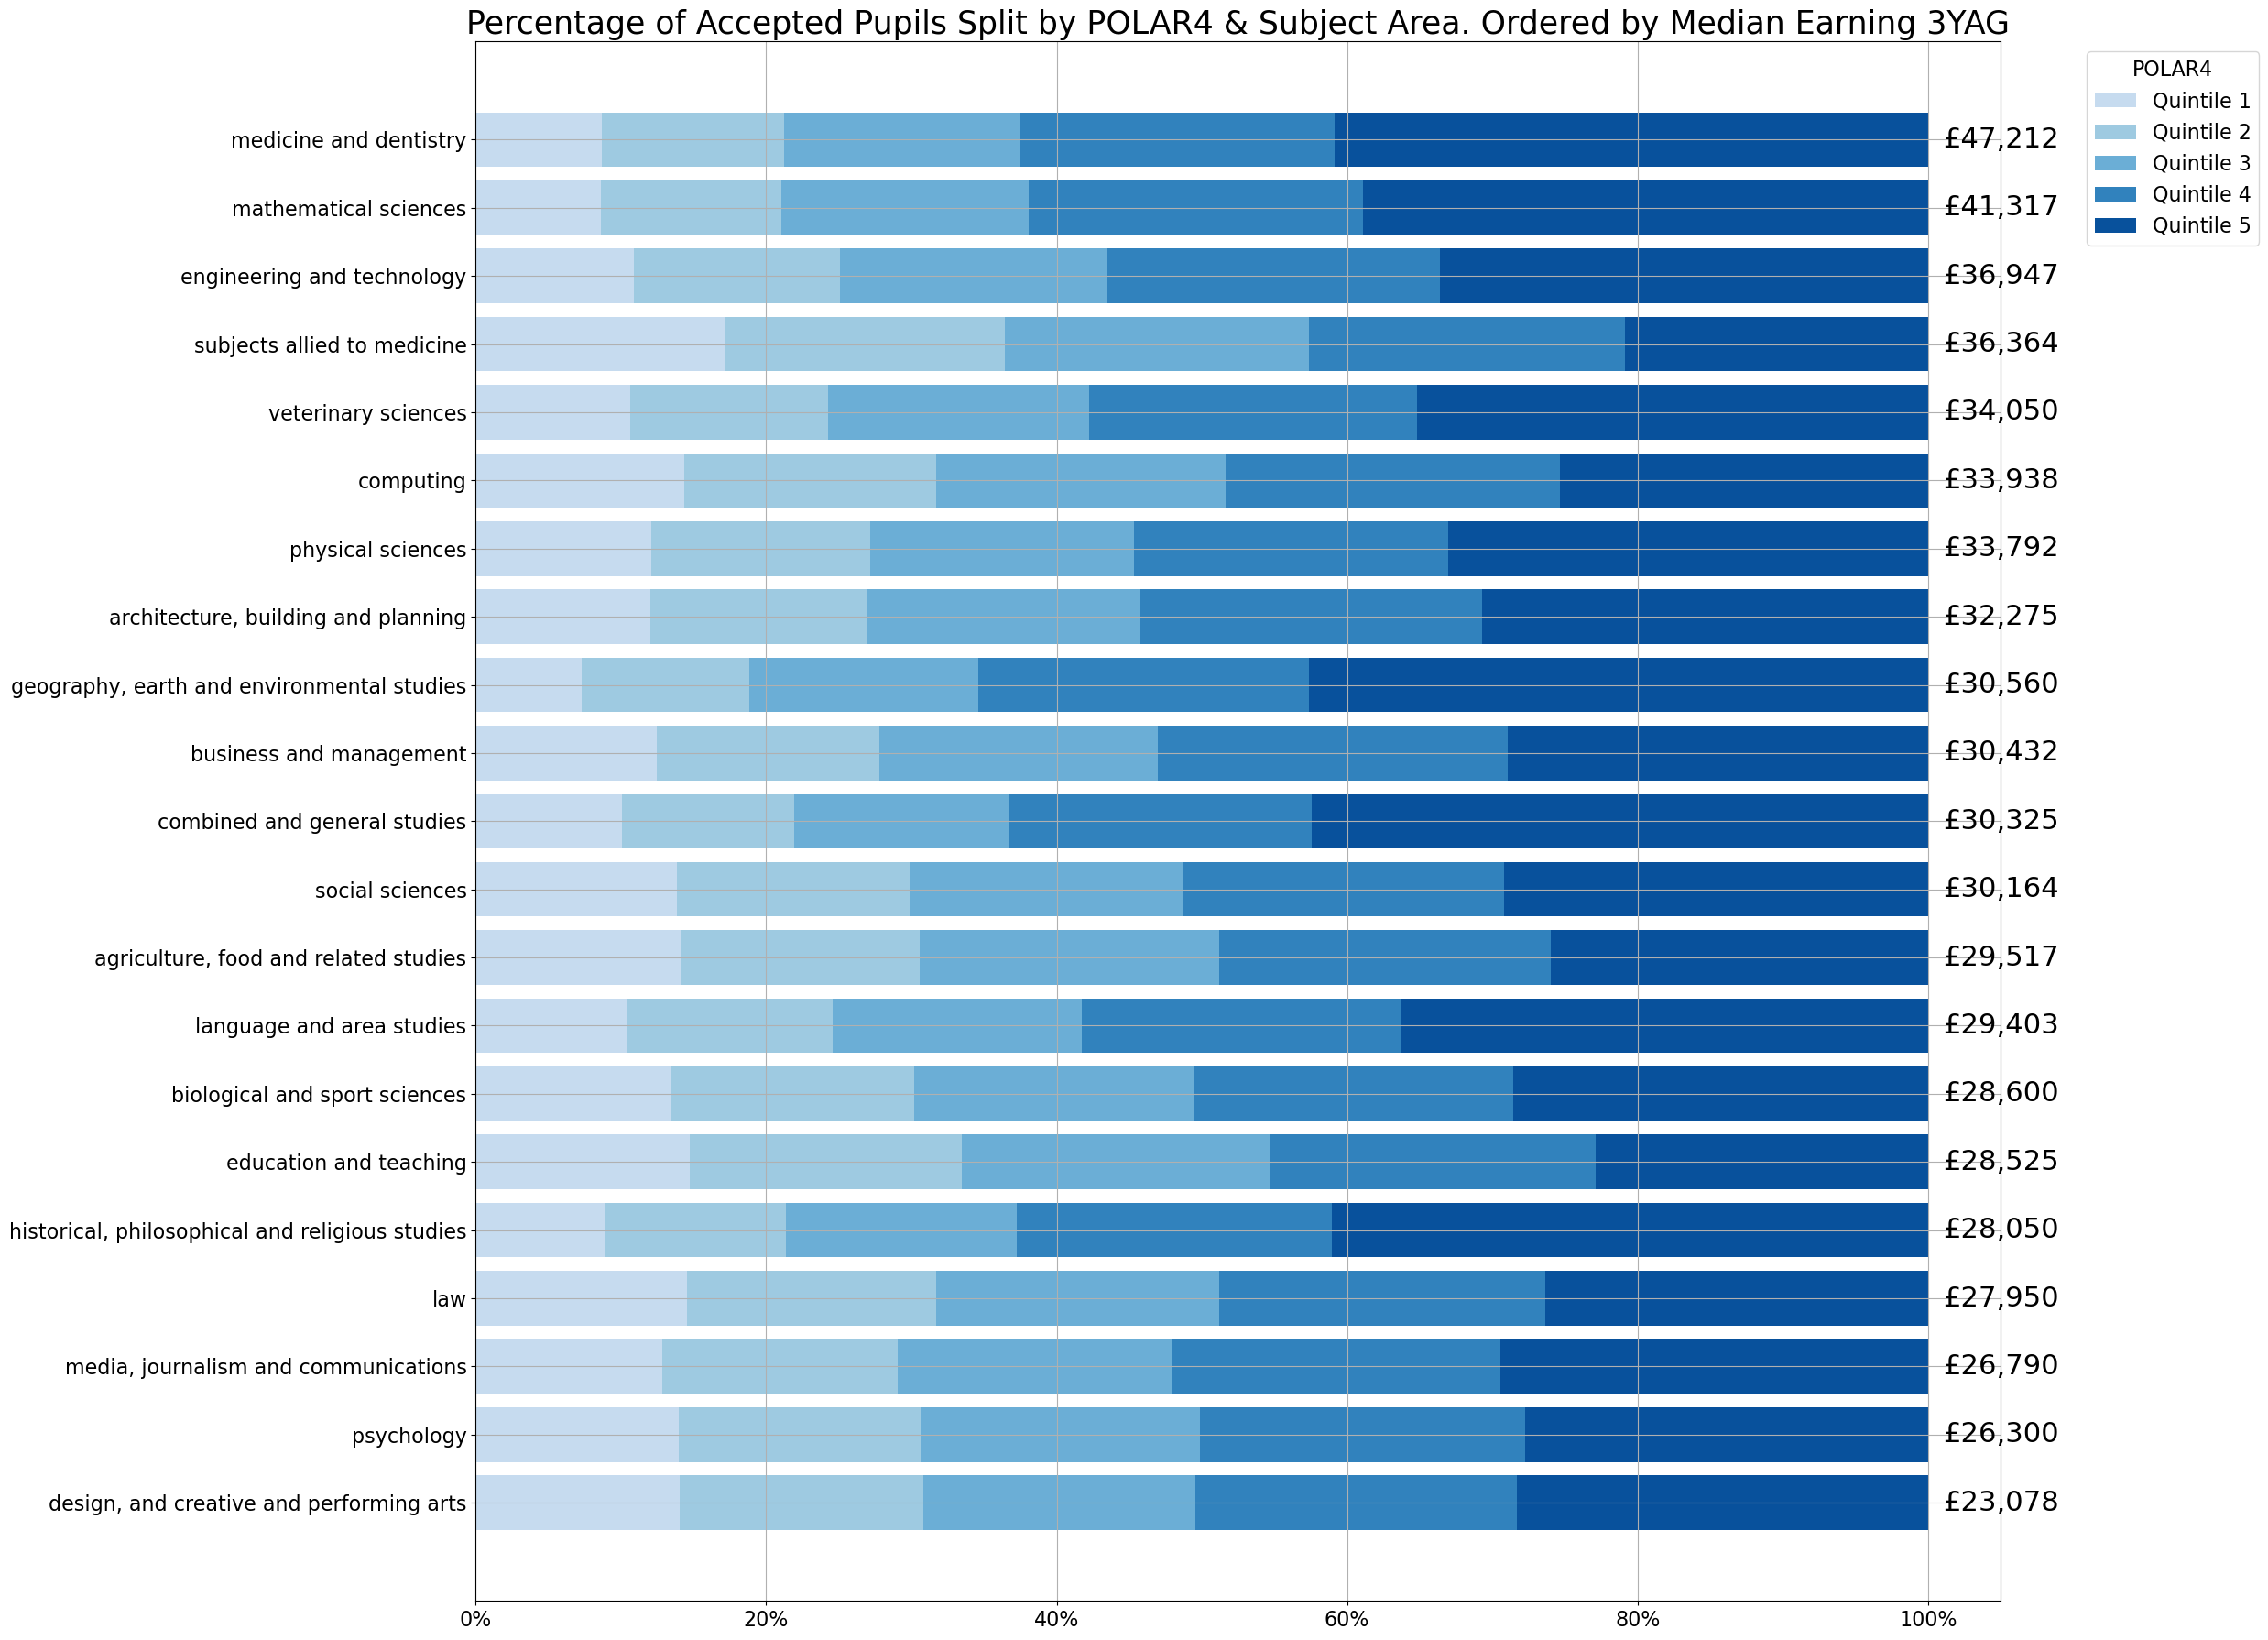

In [528]:

plt.figure(figsize= (25, 18))

plt.barh(y = pivot_table_hesa.index, width = pivot_table_hesa['Quintile 1'], label = 'Quintile 1', color = '#c6dbef')

plt.barh(y = pivot_table_hesa.index, left = pivot_table_hesa['Quintile 1'], width = pivot_table_hesa['Quintile 2'], label = 'Quintile 2', color = '#9ecae1')

plt.barh(y = pivot_table_hesa.index, left = pivot_table_hesa['Quintile 1'] + pivot_table_hesa['Quintile 2'], label = 'Quintile 3', width = pivot_table_hesa['Quintile 3'],color = '#6baed6')

plt.barh(y = pivot_table_hesa.index, left = pivot_table_hesa['Quintile 1'] + pivot_table_hesa['Quintile 2'] + pivot_table_hesa['Quintile 3'], width = pivot_table_hesa['Quintile 4'], label = 'Quintile 4', color = '#3182bd')

plt.barh(y = pivot_table_hesa.index, left = pivot_table_hesa['Quintile 1'] + pivot_table_hesa['Quintile 2'] + pivot_table_hesa['Quintile 3'] + pivot_table_hesa['Quintile 4'], width = pivot_table_hesa['Quintile 5'], label = 'Quintile 5', color = '#08519c')

plt.yticks(fontsize=18)

plt.legend(title = 'POLAR4', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, title_fontsize=16)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid()
plt.title('Percentage of Accepted Pupils Split by POLAR4 & Subject Area. Ordered by Median Earning 3YAG', fontsize = 25)

for i, subject in enumerate(pivot_table_hesa.index):
    earnings = cah1_hesa_agg[subject]
    plt.text(x=1.01, y=i, s=f'£{earnings:,.0f}', va='center', fontsize=22)

plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.tight_layout()
plt.savefig('Accepted Percentage - Ordered by Median 3YAG.jpeg')


Need to spend a bit of time looking at the quartiles during the executive report itself to draw out some meaningful analysis. 


## Comparing the data - Ranking & Ratios


Now that we have the UCAS and HESA data merged, we are keen to view this data in a way that allows us to better compare. As such, we are going to explore the use of a rank difference chart. What this will do is rank the two data datset and calculate the difference. So, we will rank the CAH1 subjects in the UCAS dataset and then do the same for median earnings from the HESA dataset. Once we have done htis, we will explore the difference to produe a rank difference chart. 


In [623]:
pivot_table_hesa.head(21)

POLAR4 Quintile,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5
Subject group HECoS CAH1,,,,,
"design, and creative and performing arts",0.140287,0.167972,0.187360,0.221048,0.283334
psychology,0.139717,0.167373,0.191884,0.223404,0.277622
"media, journalism and communications",0.128413,0.162061,0.189029,0.225850,0.294648
law,0.145505,0.171810,0.194862,0.224310,0.263514
"historical, philosophical and religious studies",0.088963,0.124318,0.159043,0.217373,0.410302
education and teaching,0.147677,0.187248,0.211596,0.224592,0.228888
biological and sport sciences,0.134211,0.167709,0.192667,0.219526,0.285887
language and area studies,0.104443,0.141212,0.171641,0.219346,0.363358
"agriculture, food and related studies",0.140823,0.164733,0.206575,0.228376,0.259494


In [533]:
pivot_table_hesa_ratio = pivot_table_hesa['Quintile 5'] / pivot_table_hesa['Quintile 1']



In [535]:
pivot_table_hesa_ratio.head()

Subject group HECoS CAH1
design, and creative and performing arts           2.019670
psychology                                         1.987032
media, journalism and communications               2.294538
law                                                1.811026
historical, philosophical and religious studies    4.612028
dtype: float64

In [572]:
equity_rank = pivot_table_hesa_ratio.rank()

In [620]:
pivot_table_hesa.head()

POLAR4 Quintile,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5
Subject group HECoS CAH1,,,,,
"design, and creative and performing arts",0.140287,0.167972,0.187360,0.221048,0.283334
psychology,0.139717,0.167373,0.191884,0.223404,0.277622
"media, journalism and communications",0.128413,0.162061,0.189029,0.225850,0.294648
law,0.145505,0.171810,0.194862,0.224310,0.263514
"historical, philosophical and religious studies",0.088963,0.124318,0.159043,0.217373,0.410302


In [573]:
equity_rank.sort_values().head()

Subject group HECoS CAH1
subjects allied to medicine              1.0
education and teaching                   2.0
computing                                3.0
law                                      4.0
agriculture, food and related studies    5.0
dtype: float64

In [581]:
earnings_rank = cah1_hesa_agg.rank(ascending=False)

In [582]:
earnings_rank.sort_values().head()

Subject group HECoS CAH1
medicine and dentistry         1.0
mathematical sciences          2.0
engineering and technology     3.0
subjects allied to medicine    4.0
veterinary sciences            5.0
Name: earnings_median, dtype: float64

In [567]:
equity_rank.index[0]

'design, and creative and performing arts'

In [568]:
earnings_rank.index[0]

'medicine and dentistry'

In [574]:
rank_diff = earnings_rank - equity_rank

In [575]:
rank_diff.head()

Subject group HECoS CAH1
agriculture, food and related studies    4.0
architecture, building and planning      2.0
biological and sport sciences           -2.0
business and management                  1.0
combined and general studies            -6.0
dtype: float64

In [576]:
rank_diff['medicine and dentistry']

np.float64(1.0)

In [583]:
print(equity_rank['medicine and dentistry'])
print(earnings_rank['medicine and dentistry'])


20.0
1.0


In [586]:
rank_diff = equity_rank - earnings_rank
print(rank_diff['medicine and dentistry'])

19.0


In [587]:
rank_diff.sort_values(ascending=False)

Subject group HECoS CAH1
medicine and dentistry                             19.0
mathematical sciences                              16.0
geography, earth and environmental studies         12.0
engineering and technology                         11.0
veterinary sciences                                10.0
physical sciences                                   6.0
combined and general studies                        6.0
architecture, building and planning                 4.0
language and area studies                           2.0
historical, philosophical and religious studies     2.0
business and management                             1.0
computing                                          -3.0
subjects allied to medicine                        -3.0
social sciences                                    -4.0
biological and sport sciences                      -6.0
agriculture, food and related studies              -8.0
media, journalism and communications               -9.0
education and teaching 

In [593]:
rank_diff_df = rank_diff.reset_index()

In [595]:
rank_diff_df.columns = ['Subject', 'Rank Difference']

In [596]:
rank_diff_df.head()

,Subject,Rank Difference
0,"agriculture, food and related studies",-8.0
1,"architecture, building and planning",4.0
2,biological and sport sciences,-6.0
3,business and management,1.0
4,combined and general studies,6.0


In [601]:
rank_diff_df = rank_diff_df.sort_values('Rank Difference', ascending=False)

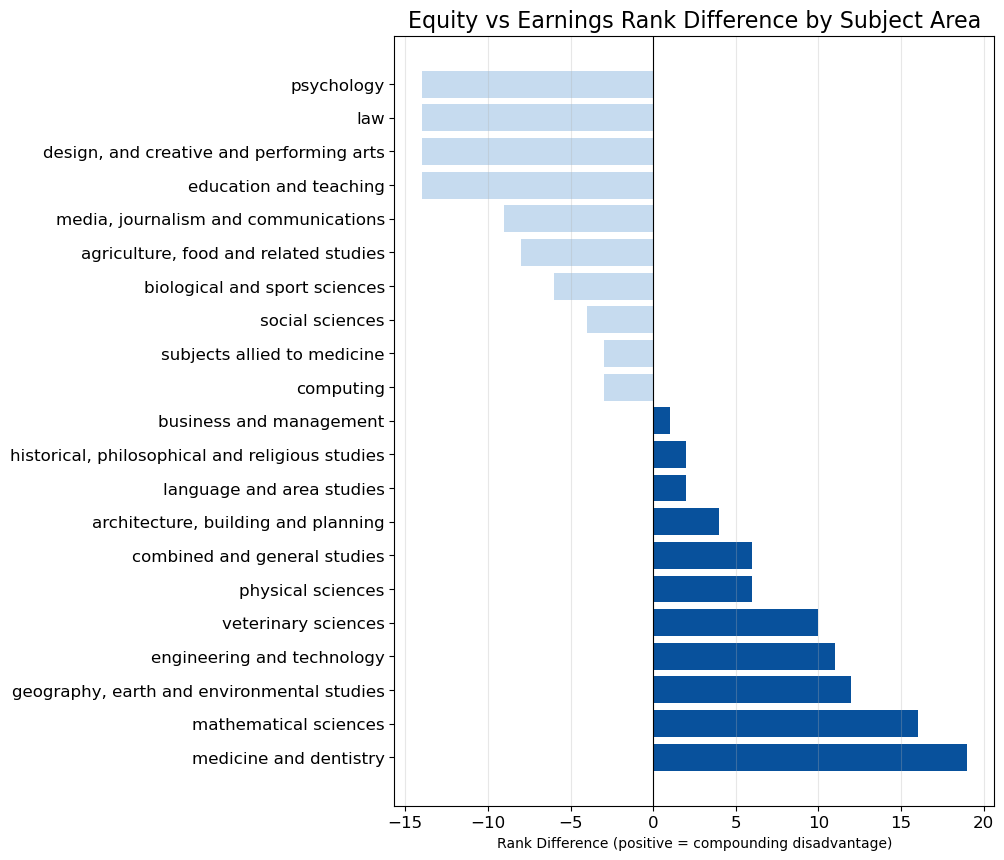

In [626]:
colors = ['#08519c' if x > 0 else '#c6dbef' for x in rank_diff_df['Rank Difference']]

plt.figure(figsize= (12, 10))
plt.barh(y=rank_diff_df['Subject'], width=rank_diff_df['Rank Difference'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Rank Difference (positive = compounding disadvantage)')
plt.title('Equity vs Earnings Rank Difference by Subject Area')
plt.grid(axis='x', alpha=0.3)
plt.title ('Equity vs Earnings Rank Difference by Subject Area', fontsize=16)
plt.yticks(fontsize=12) 
plt.xticks(fontsize=12)
plt.subplots_adjust(left=0.4)

plt.savefig('Equity Rankings.jpeg')


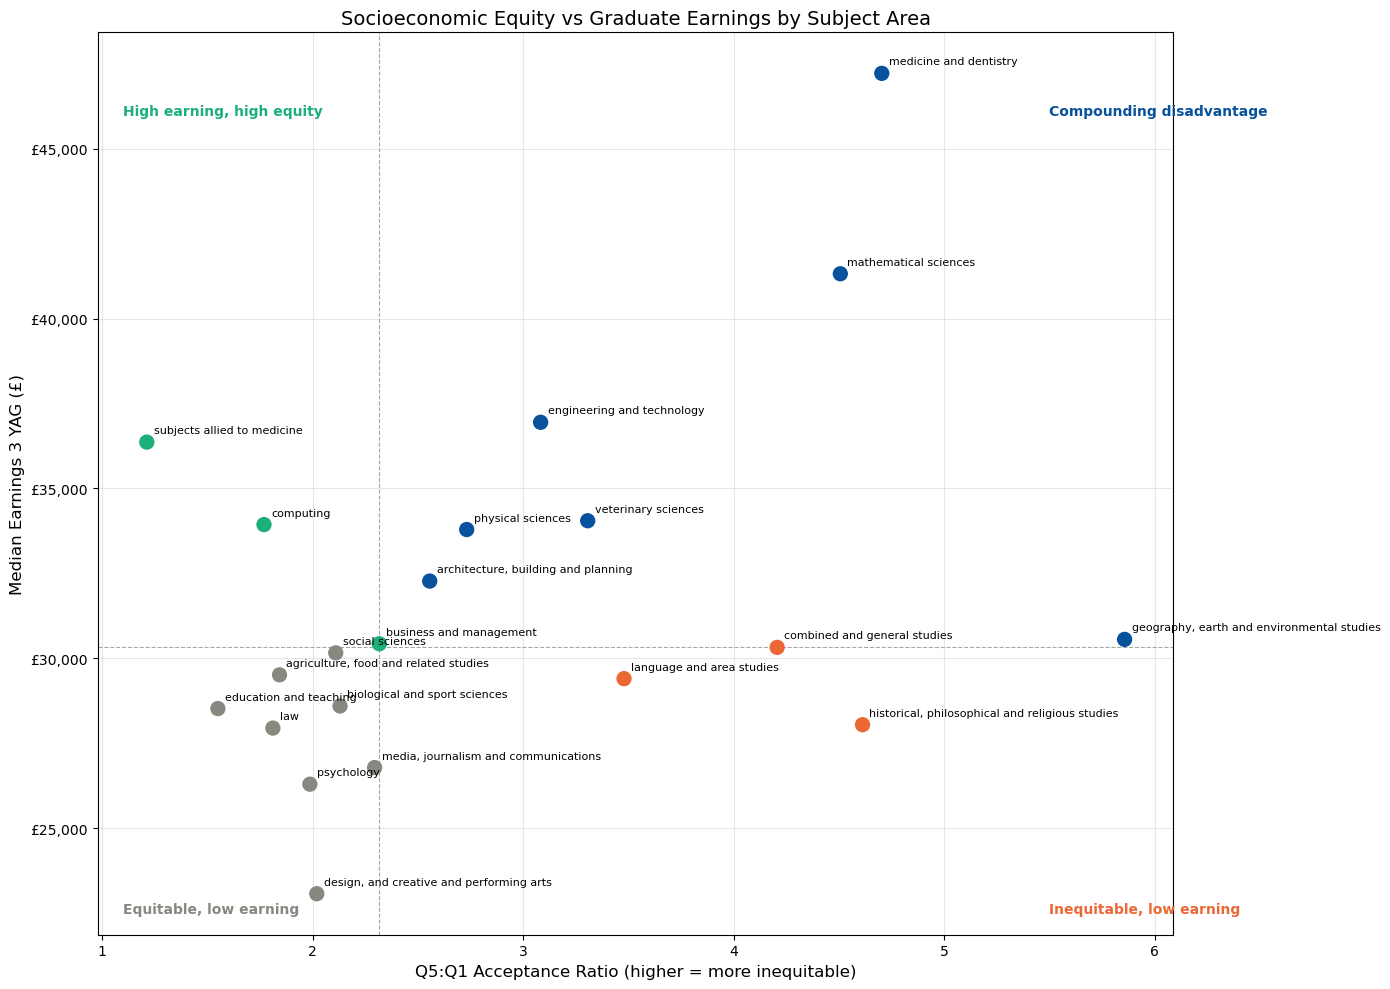

In [631]:

# Data
subjects = pivot_table_hesa_ratio.index.tolist()
ratios = pivot_table_hesa_ratio.values
earnings = [cah1_hesa_agg[s] for s in subjects]

# Median dividing lines
med_ratio = np.median(ratios)
med_earnings = np.median(earnings)

# Colours by quadrant
colors = []
for r, e in zip(ratios, earnings):
    if r > med_ratio and e > med_earnings:
        colors.append('#08519c')  # top right - compounding disadvantage
    elif r <= med_ratio and e > med_earnings:
        colors.append('#1baf7a')  # top left - high earning, high equity
    elif r > med_ratio and e <= med_earnings:
        colors.append('#eb6834')  # bottom right - inequitable, low earning
    else:
        colors.append('#888780')  # bottom left - equitable, low earning

fig, ax = plt.subplots(figsize=(14, 10))

# Plot dots
ax.scatter(ratios, earnings, c=colors, s=100, zorder=3)

# Quadrant lines
ax.axvline(x=med_ratio, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=med_earnings, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

# Labels
for i, subject in enumerate(subjects):
    ax.annotate(subject, (ratios[i], earnings[i]), 
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

# Quadrant labels
ax.text(5.5, 46000, 'Compounding disadvantage', color='#08519c', fontsize=10, fontweight='bold')
ax.text(1.1, 46000, 'High earning, high equity', color='#1baf7a', fontsize=10, fontweight='bold')
ax.text(5.5, 22500, 'Inequitable, low earning', color='#eb6834', fontsize=10, fontweight='bold')
ax.text(1.1, 22500, 'Equitable, low earning', color='#888780', fontsize=10, fontweight='bold')

ax.set_xlabel('Q5:Q1 Acceptance Ratio (higher = more inequitable)', fontsize=12)
ax.set_ylabel('Median Earnings 3 YAG (£)', fontsize=12)
ax.set_title('Socioeconomic Equity vs Graduate Earnings by Subject Area', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Quadrant_scatter.jpeg', bbox_inches='tight')
plt.show()

## Exploring the IMD Deprivation Dataset

In [632]:
imd_df = pd.read_csv('/Users/anatoly/Desktop/Imperial - Data Analytics/Capstone Project/HE Capstone - Final Data Sources/imd_clean.csv')

In [633]:
imd_df.head()

,Year,Subject group HECoS CAH1,Subject group HECoS CAH3,IMD Aggregated,Accepted applicants
0,2019,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,2600
1,2020,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,2665
2,2021,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,2605
3,2022,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,2620
4,2023,"(CAH25) design, and creative and performing arts",(CAH25-01-03) design studies,Quintile 1,2540


In [635]:
biv_imd = imd_df.groupby(['Subject group HECoS CAH1', 'IMD Aggregated'])['Accepted applicants'].sum()

In [636]:
biv_imd.head()

Subject group HECoS CAH1        IMD Aggregated
(CAH01) medicine and dentistry  Quintile 1        10590
                                Quintile 2        11250
                                Quintile 3        12085
                                Quintile 4        14425
                                Quintile 5        20145
Name: Accepted applicants, dtype: int64

In [639]:
biv_imd = biv_imd.reset_index()


In [640]:
biv_imd_accept_share = imd_df.groupby(['Subject group HECoS CAH1'])['Accepted applicants'].sum()

In [641]:
biv_imd['Acceptance share'] = biv_imd['Accepted applicants'] / biv_imd['Subject group HECoS CAH1'].map(biv_imd_accept_share)

In [642]:
biv_imd.head()

,Subject group HECoS CAH1,IMD Aggregated,Accepted applicants,Acceptance share
0,(CAH01) medicine and dentistry,Quintile 1,10590,0.154610
1,(CAH01) medicine and dentistry,Quintile 2,11250,0.164246
2,(CAH01) medicine and dentistry,Quintile 3,12085,0.176436
3,(CAH01) medicine and dentistry,Quintile 4,14425,0.210599
4,(CAH01) medicine and dentistry,Quintile 5,20145,0.294109


In [647]:
pivot_table_imd = pd.pivot_table(biv_imd, 
                   index = 'Subject group HECoS CAH1', 
                   columns = 'IMD Aggregated',
                  values = 'Acceptance share',
                            ).sort_values(by = 'Quintile 1')
pivot_table_imd.index = pivot_table_imd.index.str.split(')').str[1].str.strip()

In [648]:
pivot_table_imd.head()

IMD Aggregated,Quintile 1,Quintile 2,Quintile 3,Quintile 4,Quintile 5
Subject group HECoS CAH1,,,,,
"geography, earth and environmental studies",0.075064,0.127287,0.190314,0.254573,0.352763
veterinary sciences,0.097788,0.139697,0.207994,0.252619,0.301901
"historical, philosophical and religious studies",0.106169,0.147713,0.196653,0.242394,0.307071
mathematical sciences,0.124210,0.161029,0.183431,0.226794,0.304536
language and area studies,0.132365,0.163003,0.195058,0.229107,0.280468


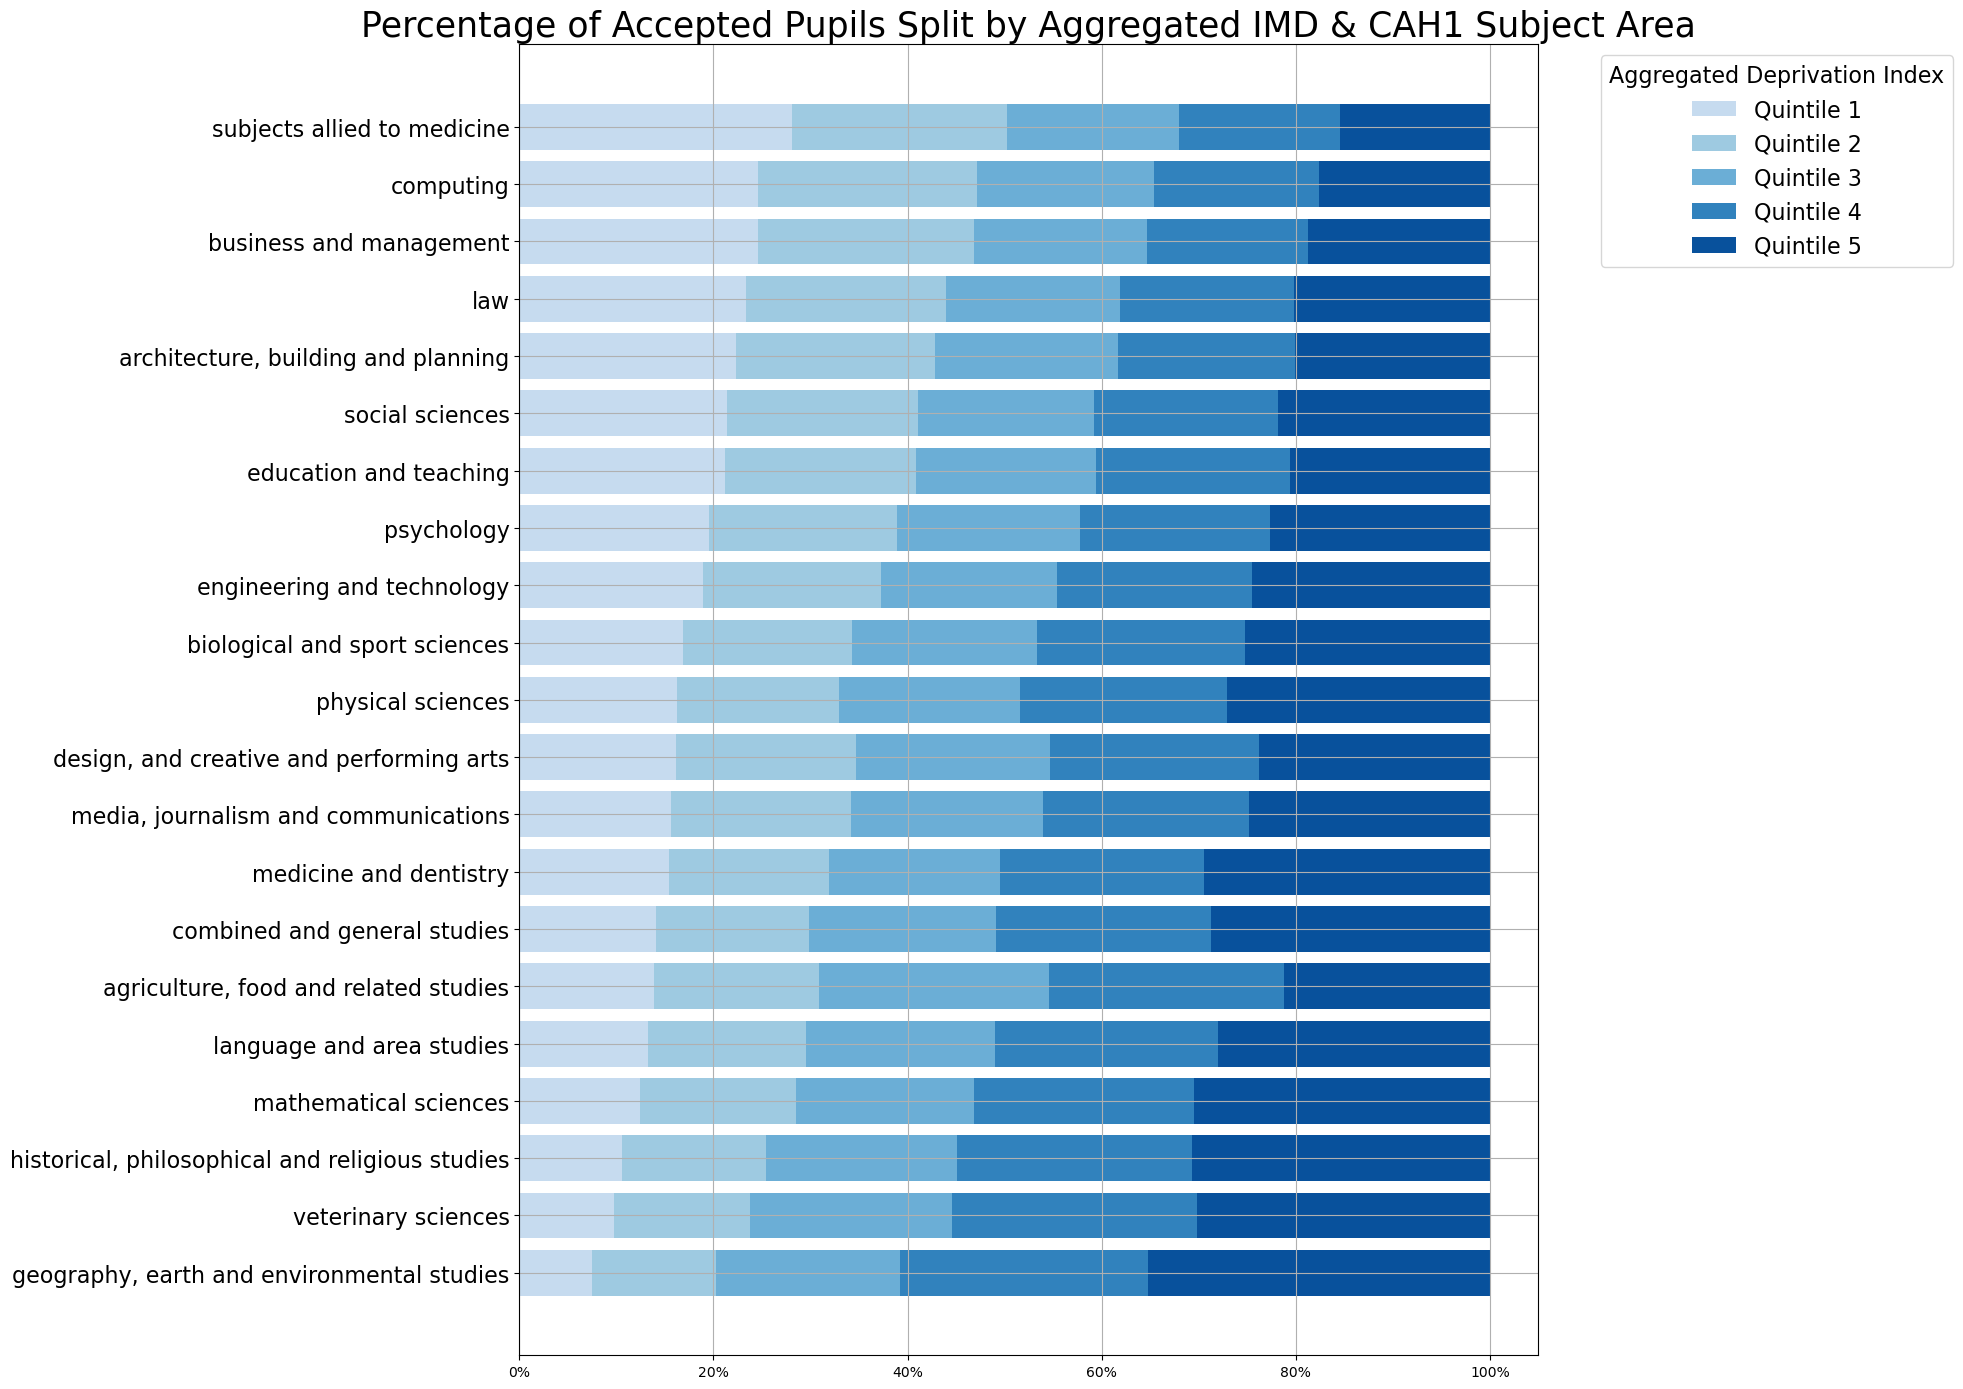

In [661]:
plt.figure(figsize= (20, 14))

plt.barh(y = pivot_table_imd.index, width = pivot_table_imd['Quintile 1'], label = 'Quintile 1', color = '#c6dbef')

plt.barh(y = pivot_table_imd.index, left = pivot_table_imd['Quintile 1'], width = pivot_table_imd['Quintile 2'], label = 'Quintile 2', color = '#9ecae1')

plt.barh(y = pivot_table_imd.index, left = pivot_table_imd['Quintile 1'] + pivot_table_imd['Quintile 2'], label = 'Quintile 3', width = pivot_table_imd['Quintile 3'],color = '#6baed6')

plt.barh(y = pivot_table_imd.index, left = pivot_table_imd['Quintile 1'] + pivot_table_imd['Quintile 2'] + pivot_table_imd['Quintile 3'], width = pivot_table_imd['Quintile 4'], label = 'Quintile 4', color = '#3182bd')

plt.barh(y = pivot_table_imd.index, left = pivot_table_imd['Quintile 1'] + pivot_table_imd['Quintile 2'] + pivot_table_imd['Quintile 3'] + pivot_table_imd['Quintile 4'], width = pivot_table_imd['Quintile 5'], label = 'Quintile 5', color = '#08519c')

plt.legend(title='Aggregated Deprivation Index', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, title_fontsize=16)

plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.grid()
plt.title('Percentage of Accepted Pupils Split by IMD & Subject Area')
plt.yticks(fontsize=16)
plt.title('Percentage of Accepted Pupils Split by Aggregated IMD & CAH1 Subject Area', fontsize=25)
plt.tight_layout()
plt.savefig('IMD Accepted Percentage - Ordered.jpeg')


In [653]:
pivot_table_imd_ratio = pivot_table_imd['Quintile 5'] / pivot_table_imd['Quintile 1']



In [654]:
pivot_table_imd_ratio.head()

Subject group HECoS CAH1
geography, earth and environmental studies         4.699495
veterinary sciences                                3.087302
historical, philosophical and religious studies    2.892292
mathematical sciences                              2.451786
language and area studies                          2.118906
dtype: float64

In [655]:
equity_rank_imd = pivot_table_imd_ratio.rank()

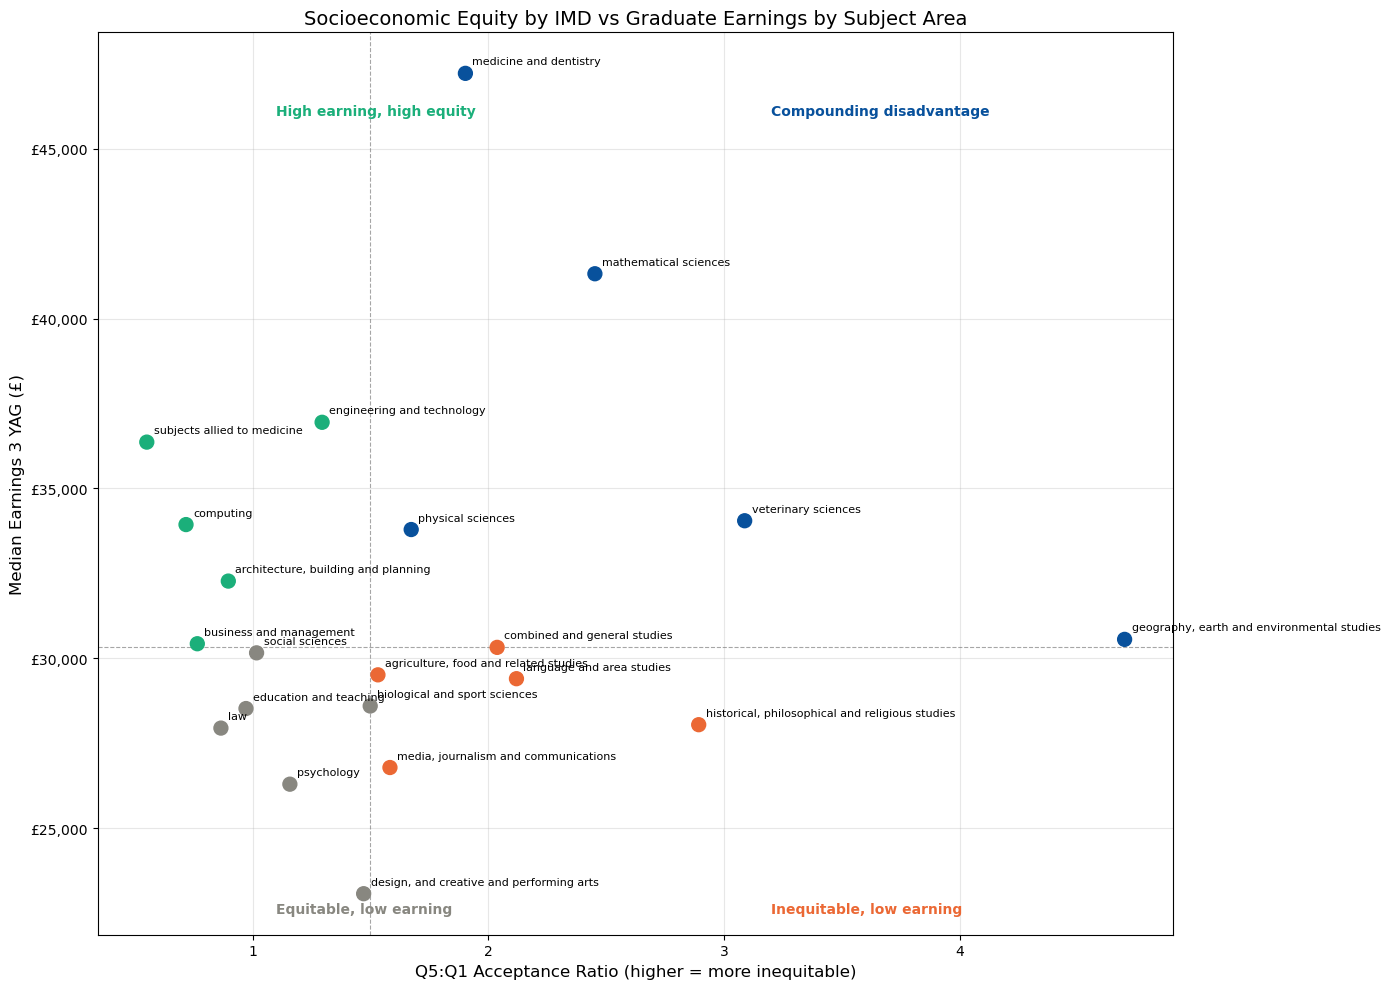

In [660]:

# Data
subjects_imd = pivot_table_imd_ratio.index.tolist()
ratios_imd= pivot_table_imd_ratio.values
earnings_imd = [cah1_hesa_agg[s] for s in subjects_imd]

# Median dividing lines
med_ratio_imd = np.median(ratios_imd)
med_earnings_imd = np.median(earnings_imd)

# Colours by quadrant
colors = []
for r, e in zip(ratios_imd, earnings_imd):
    if r > med_ratio_imd and e > med_earnings_imd:
        colors.append('#08519c')  # top right - compounding disadvantage
    elif r <= med_ratio_imd and e > med_earnings_imd:
        colors.append('#1baf7a')  # top left - high earning, high equity
    elif r > med_ratio_imd and e <= med_earnings_imd:
        colors.append('#eb6834')  # bottom right - inequitable, low earning
    else:
        colors.append('#888780')  # bottom left - equitable, low earning

fig, ax = plt.subplots(figsize=(14, 10))

# Plot dots
ax.scatter(ratios_imd, earnings_imd, c=colors, s=100, zorder=3)

# Quadrant lines
ax.axvline(x=med_ratio_imd, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axhline(y=med_earnings_imd, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

# Labels
for i, subject in enumerate(subjects_imd):
    ax.annotate(subject, (ratios_imd[i], earnings_imd[i]), 
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

# Quadrant labels
ax.text(3.2, 46000, 'Compounding disadvantage', color='#08519c', fontsize=10, fontweight='bold')
ax.text(1.1, 46000, 'High earning, high equity', color='#1baf7a', fontsize=10, fontweight='bold')
ax.text(3.2, 22500, 'Inequitable, low earning', color='#eb6834', fontsize=10, fontweight='bold')
ax.text(1.1, 22500, 'Equitable, low earning', color='#888780', fontsize=10, fontweight='bold')

ax.set_xlabel('Q5:Q1 Acceptance Ratio (higher = more inequitable)', fontsize=12)
ax.set_ylabel('Median Earnings 3 YAG (£)', fontsize=12)
ax.set_title('Socioeconomic Equity by IMD vs Graduate Earnings by Subject Area', fontsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('IMD_Quadrant_scatter.jpeg', bbox_inches='tight')
plt.show()

In [658]:
print(pivot_table_hesa_ratio.index[:3])
print(pivot_table_imd_ratio.index[:3])

Index(['design, and creative and performing arts', 'psychology',
       'media, journalism and communications'],
      dtype='object', name='Subject group HECoS CAH1')
Index(['geography, earth and environmental studies', 'veterinary sciences',
       'historical, philosophical and religious studies'],
      dtype='object', name='Subject group HECoS CAH1')


In [659]:
correlation = pivot_table_hesa_ratio.corr(pivot_table_imd_ratio)
print(correlation)

0.8511448121895987
